## 텍스트 빈도 분석 실습

**실습 목표:**

1. **텍스트 전처리 파이프라인** (정규표현식, 정규화, 불용어, 형태소 분석)을 구축할 수 있다
2. **N-gram** 과 **TF-IDF** 를 활용하여 핵심 키워드를 추출할 수 있다
3. **워드클라우드** 로 텍스트 분석 결과를 시각화할 수 있다
4. **별점별 키워드 변화** 를 추적하여 세밀한 감성 차이를 분석할 수 있다
5. **동시출현(Co-occurrence) 분석** 으로 단어 간 관계를 **네트워크** 로 시각화할 수 있다

**데이터:** 자세교정 밴드 제품 리뷰 데이터 (1,500건, 별점 1~5)

In [ ]:
# 필요한 패키지를 한 번에 설치합니다
# !pip install -q kiwipiepy pandas matplotlib seaborn wordcloud scikit-learn tqdm networkx

# uv 권장! uv 환경에서는 위 pip 대신 터미널에서 uv sync 명령어로 설치하세요:
# uv sync


In [ ]:
# 라이브러리 임포트
import platform
import json
import os
from pprint import pprint
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud
from itertools import combinations
from collections import Counter
import networkx as nx


# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

### 1. 데이터 로드 및 탐색

**자세교정 밴드 제품 리뷰** 데이터를 사용합니다.

- 쿠팡에서 수집한 자세교정 밴드 제품 리뷰 데이터셋 (1,500건, 7개 옵션)
- **전체 옵션** 을 통합하여 분석합니다
- 각 리뷰에 **별점(1~5)** 이 부여되어 있습니다
- 별점 4~5를 **긍정(1)**, 별점 1~3을 **부정(0)** 으로 분류하여 분석합니다

| 컬럼 | 설명 |
|------|------|
| `content` | 리뷰 본문 텍스트 |
| `rating` | 별점 (1~5) |
| `itemName` | 제품 옵션명 |
| `displayName` | 작성자 |
| `helpfulCount` | 도움이 됐어요 수 |
| `createdAt` | 작성일 |

In [ ]:
# JSON 파일에서 제품 리뷰 데이터를 로드합니다
data_path = os.path.join(os.getcwd(), 'data', '쿠팡 리뷰 수집_7518948286.json')
df = pd.read_json(data_path, encoding='utf-8')

# 옵션별 리뷰 수를 확인합니다
print("옵션별 리뷰 수:")
pprint(df['itemName'].value_counts())

print(f"\n전체 데이터 크기: {df.shape}")
display(df.head())

In [ ]:
# 데이터의 기본 정보를 살펴보겠습니다
print("=" * 50)
print("데이터 기본 정보")
print("=" * 50)
print(f"전체 리뷰 수: {len(df):,}건")

print(f"\n별점 분포:")
print(df['rating'].value_counts().sort_index())

null_count = df['content'].isnull().sum()
empty_count = (df['content'].fillna('').str.strip() == '').sum()
print(f"빈 리뷰: {empty_count}건")

In [ ]:
# 결측치 제거
df = df.dropna(subset=['content']) #null 제거 
df = df[df['content'].str.strip() != ''].reset_index(drop=True) # "" 비어있는 텍스트 제거
print(f"유효 리뷰: {len(df):,}건")

# 별점 기준으로 긍정/부정 라벨 생성 (4~5점 => 긍정(1), 1~3점 => 부정(0))
df['label'] = (df['rating'] >= 4).astype(int)

print(f"\n긍정(별점 4-5): {(df['label'] == 1).sum():,}건")
print(f"부정(별점 1-3): {(df['label'] == 0).sum():,}건")

df_sample = df.copy()
print(f"\n분석 대상: {len(df_sample):,}건")
display(df_sample[['content', 'rating', 'label']].head())

### 2. 텍스트 전처리 파이프라인

텍스트 데이터는 원본 그대로 분석하면 **노이즈(잡음)** 가 너무 많습니다.

HTML 태그, URL, 특수문자, 오타, 반복 문자 등이 섞여 있기 때문입니다.

따라서 분석 전에 아래와 같은 **전처리 파이프라인** 을 거쳐 텍스트를 깔끔하게 정리합니다.

 ![텍스트 전처리 파이프라인](images/1_preprocessing_pipeline.png)


| 단계 | 이름 | 핵심 목적 | 예시 |
|------|------|-----------|------|
| (1) |**정제 (Cleaning)**| 분석에 불필요한 문자/기호를 제거 | `<b>최고!</b> 10점~` => `최고` |
| (2) |**정규화 (Normalization)**| 같은 의미의 다른 표현을 통일 | `ㅋㅋㅋㅋㅋ` => `ㅋㅋ`, `GOOD` => `good` |
| (3) |**형태소 분석 (Tokenization)**| 문장을 의미 단위(형태소)로 분리 | `재미있었습니다` => `재미`, `있`, `었`, `습니다` |
| (4) |**불용어 제거 (Stopword Removal)**| 분석에 무의미한 고빈도 단어 제거 | `제품`, `사용`, `구매` 등 제외 |

**정규 표현식 기본 문법을 살펴볼까요?**

| 패턴 | 의미 | 예시 |
|------|------|------|
| `.` | 아무 문자 1개 | `a.c` : "abc", "a1c" |
| `?` | 앞 문자 0회 또는 1회 (있어도 되고 없어도 됨) | `ab?c` : "ac", "abc" |
| `*` | 앞 문자 0회 이상 반복 | `ab*c` : "ac", "abc", "abbc" |
| `+` | 앞 문자 1회 이상 반복 | `ab+c` : "abc", "abbc" |
| `{n}` | 앞 문자 정확히 n회 반복 | `a{3}` : "aaa" |
| `{n,}` | 앞 문자 n회 이상 반복 | `a{2,}` : "aa", "aaa", "aaaa" |
| `{n,m}` | 앞 문자 n회 이상 m회 이하 반복 | `a{2,4}` : "aa", "aaa", "aaaa" |
| `\d` | 숫자 (0-9) | `\d+` : "123", "42" |
| `\D` | 숫자가 아닌 문자 (`\d`의 반대) | `\D+` : "abc", "가나다" |
| `\w` | 단어 문자 (유니코드 문자, 숫자, 밑줄 `_`) | `\w+` : "hello", "안녕123" |
| `\W` | 단어 문자가 아닌 문자 (`\w`의 반대) | `\W+` : "!@#", "  " |
| `\s` | 공백 문자 (스페이스, 탭, 줄바꿈) | `\s+` : 연속된 공백 매칭 |
| `\S` | 공백이 아닌 문자 (`\s`의 반대) | `http\S+` : URL 매칭 |
| `[abc]` | a, b, c 중 하나 | `[가-힣]+` : 한글 문자열 |
| `[^abc]` | a, b, c를 제외한 문자 | `[^가-힣]` : 한글이 아닌 모든 문자 |
| `(.)` | 아무 문자 1개를 그룹으로 캡처 | `(.)\1` : 같은 문자 2번 반복 |
| `\1` | 첫 번째 캡처 그룹을 역참조 | `(.)\1{2,}` : 같은 문자 3번 이상 반복 |
| `re.sub(패턴, 대체, 텍스트)` | 패턴을 찾아 대체 | `re.sub(r'\d+', '', text)` => 숫자 제거 |

#### (1) 정제 (Cleaning)

**정제** 란 텍스트에서 **분석에 불필요한 노이즈를 제거** 하는 과정입니다.

웹에서 수집한 텍스트에는 다양한 노이즈가 포함되어 있습니다:

| 제거 대상 | 예시 | 이유 |
|-----------|------|------|
|**HTML 태그**| `<b>`, `<br>`, `<div>` | 웹 크롤링 시 함께 수집됨 |
|**URL**| `http://link.com` | 분석에 무의미한 링크 |
|**특수문자/이모지**| `!!!`, `@user`, `#태그`, `~` | 텍스트 의미 분석에 불필요 |
|**숫자**| `10점`, `2024년` | 도메인에 따라 제거 여부 결정 |
|**여러 공백**| `"영화  정말   좋다"` | 하나의 공백으로 정리 |

먼저 간단한 예시로 정규 표현식이 어떻게 동작하는지 확인해봅시다.

In [ ]:
# 정규 표현식으로 텍스트를 정제하는 예시입니다
sample_text = "<b>자세교정</b> 밴드!!! 효과 완전 좋아요~ @user #자세밴드추천 http://link.com"

print(f"원본:           {sample_text}")
print()

text = sample_text

# 1단계: HTML 태그 제거 (re.sub으로 <...> 패턴을 찾아 제거)
text = re.sub(r'<[^>]+>', '', text)

print(f"[1] HTML 태그 제거: {text}")

# 2단계: URL 제거 (http로 시작하는 문자열 제거)
text = re.sub(r'http\S+', '', text) 
print(f"[2] URL 제거:       {text}")

# 3단계: 한글/영문/숫자/공백만 남기기
text = re.sub(r'[^가-힣a-zA-Z\d\s]', ' ', text)
print(f"[3] 특수문자 제거:  {text}")

# 4단계: 여러 공백을 하나로 정리
text = re.sub(r'\s+', ' ', text).strip()
print(f"[4] 공백 정리:      {text}")


In [ ]:
def clean_text(text):
    """
    텍스트 정제 함수
    - HTML 태그, URL, 특수문자를 제거합니다
    - 한글, 영문, 숫자, 공백만 남깁니다
    """
    if not isinstance(text, str): #타입을 체크하는 함수 
        return ""

    # 1단계: HTML 태그 제거
    text = re.sub(r'<[^>]+>', '', text)

    # 2단계: URL 제거
    text = re.sub(r'http\S+', '', text) 

    # 3단계: 한글, 영문, 숫자, 공백만 남기기
    text = re.sub(r'[^가-힣a-zA-Z\d\s]', ' ', text)

    # 4단계: 여러 공백을 하나로 정리
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# 테스트
test_texts = [
    "자세교정 효과 좋아요ㅋㅋㅋ 강추!!!",
    "어깨가 너무 조여서 별로... 사이즈 안 맞음 ㅠㅠ",
    "http://link.com 이 자세밴드 추천합니다~"
]

for t in test_texts:
    print(f"원본: {t}")
    print(f"정제: {clean_text(t)}")
    print("-" * 50)

#### (2) 정규화 (Normalization)

**정규화** 란 **같은 의미를 가진 다른 표현들을 하나의 통일된 형태로 변환** 하는 과정입니다.

정제가 "불필요한 것을 제거"하는 것이라면, 정규화는 "다양한 표현을 하나로 통일"하는 것입니다.

| 정규화 유형 | 변환 전 | 변환 후 | 설명 |
|-------------|---------|---------|------|
|**반복 문자 축소**| `ㅋㅋㅋㅋㅋ`, `ㅠㅠㅠㅠ` | `ㅋㅋ`, `ㅠㅠ` | 과도한 반복을 일정 횟수로 제한 |
|**대소문자 통일**| `Good`, `GOOD`, `good` | `good` | 영문 텍스트의 표기 통일 |
|**유니코드 정규화**| 호환 문자 (㈜, ㎝) | 표준 문자 | 동일 문자의 다른 인코딩 통일 |

> **이번 실습에서는** 정규표현식으로 **반복 문자 축소** 를 적용합니다.

In [ ]:
def normalize_text(text):
    """
    텍스트 정규화 함수
    - 같은 문자가 3번 이상 반복되면 2번으로 줄입니다
    - 예: ㅋㅋㅋㅋㅋ => ㅋㅋ
    """
    # 같은 문자가 3번 이상 반복되는 패턴을 찾아 2번으로 축소
    # 힌트: (.)\1{2,} 패턴과 \1\1 대체를 사용
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    return text

# 테스트
print(normalize_text("촉촉해요ㅋㅋㅋㅋㅋㅋ"))  # => 촉촉해요ㅋㅋ
print(normalize_text("별로다ㅠㅠㅠㅠ"))        # => 별로다ㅠㅠ
print(normalize_text("진짜짜짜짜 좋아요"))     # => 진짜짜 좋아요


#### (3) 형태소 분석 (토큰화)

**영어와 한국어의 토큰화, 무엇이 다를까요?**

| | 영어 | 한국어 |
|---|---|---|
| 토큰화 방법 | 공백으로 쉽게 분리 가능 | 형태소 분석이 반드시 필요합니다 |
| 이유 | 단어가 독립적으로 존재 | 교착어이므로 조사/어미가 결합되어 있습니다 |
| 예시 | "I love this band" => ["I", "love", "this", "band"] | "자세교정이 됩니다" => ["자세", "교정", "이", "되", "ㅂ니다"] |

**kiwipiepy 소개**
- 한국어 형태소 분석기로, C++로 작성되어 빠른 속도와 높은 정확도를 제공합니다
- 다른 패키지에 의존성이 없으므로 pip만으로 설치가 완료됩니다 (Java 불필요)
- 공식 문서: https://bab2min.github.io/kiwipiepy/

**`kiwi.tokenize()` 주요 파라미터**

| 파라미터 | 타입 | 기본값 | 설명 |
|----------|------|--------|------|
| `text` | str 또는 Iterable[str] | (필수) | 분석할 문자열. Iterable로 주면 멀티스레드 병렬 처리 |
| `normalize_coda` | bool | False | 덧붙은 받침을 분리하여 정규화. 예: "먹었엌ㅋㅋ" => "먹었어" + "ㅋㅋㅋ" |
| `z_coda` | bool | True | 조사/어미에 덧붙은 받침을 분리. 예: "먹었어욥" => "먹었어요" + "ㅂ" |
| `split_complex` | bool | False | 파생어를 최대한 분할. 예: "고마움" => "고맙" + "음" |
| `split_sents` | bool | False | 결과를 문장 단위로 묶어서 반환 |
| `stopwords` | Stopwords | None | `kiwipiepy.utils.Stopwords` 객체를 주면 불용어를 자동 제거 |
| `blocklist` | MorphemeSet | None | 특정 형태소가 결과에 등장하는 것을 금지. 예: `['고마움/NNG']` |

**`Kiwi()` 생성자의 주요 파라미터**

| 파라미터 | 타입 | 기본값 | 설명 |
|----------|------|--------|------|
| `num_workers` | int | None | 멀티스레드 워커 수. None이면 모든 코어 사용 |
| `typos` | str 또는 None | None | 오타 교정 활성화. 아래 표 참고 (초기 로딩 5~10초, 처리 속도 2배 느려짐) |
| `typo_cost_threshold` | float | 2.5 | 오타 교정 허용 범위. 값이 클수록 더 많은 오타를 교정 (과교정 주의) |
| `model_type` | str | "cong" | 언어 모델 선택. "cong"(기본, 빠르고 정확), "cong-global"(더 먼 거리 문맥 고려) |

**오타 교정 종류 (`typos` 파라미터)**

| 값 | 설명 | 예시 |
|----|------|------|
| `'basic'` | 형태소 내 오타 교정 | "외않됀대?" => "왜 안 되ㄴ대?" |
| `'continual'` | 연철 오타 교정 (음절 경계 오류) | "사무시레서" => "사무실에서" |
| `'lengthening'` | 음절 늘려 적기 교정 | "지인짜" => "진짜" |
| `'basic_with_continual'` | basic + continual 결합 | "웨 지가캤니?" => "왜 지각했니?" |
| `'basic_with_continual_and_lengthening'` | 위 세 가지 모두 결합 | 가장 넓은 범위의 오타 교정 |

> **참고:** 오타 교정 기능을 사용하면 Kiwi 초기화 시 5~10초 추가 소요, 분석 속도 약 2배 느려짐, 메모리 2~3배 증가합니다. 분석 정확도와 속도 간의 트레이드오프를 고려하여 선택하세요.

In [ ]:
# Kiwi 형태소 분석기를 초기화합니다
kiwi = Kiwi()

# 예시 문장으로 형태소 분석을 수행합니다
example = "이 자세교정 밴드는 정말 효과가 좋습니다"
result = kiwi.tokenize(example, normalize_coda=True)

print(f"원문: {example}")
print(f"형태소 분석: {result}")
print()

# 각 형태소의 품사 태그 설명
tag_map = {
    'NNG': '일반명사', 'NNP': '고유명사', 'NR': '수사',
    'VA': '형용사', 'VV': '동사', 'VCP': '긍정지정사(이다)',
    'MAG': '부사', 'MM': '관형사', 'IC': '감탄사',
    'JKS': '주격조사', 'JKO': '목적격조사', 'JKG': '관형격조사', 'JX': '보조사',
    'EP': '선어말어미', 'EF': '종결어미', 'EC': '연결어미',
    'XSV': '동사파생접미사', 'XSN': '명사파생접미사',
    'SN': '숫자', 'SW': '특수문자', 'SF': '마침표',
    'VX': '보조용언', 'XSA': '형용사파생접미사',
}

morph_df = pd.DataFrame([
    {'형태소': token.form, '품사태그': token.tag, '의미': tag_map.get(token.tag, token.tag)}
    for token in result
])
display(morph_df)


In [ ]:
def extract_morphs(text):
    """
    형태소 분석 후 명사(NNG, NNP)와 형용사(VA)만 추출합니다
    - 1글자 단어는 제외합니다
    """
    if not text or not isinstance(text, str):
        return []

    # 추출할 품사 태그를 지정합니다
    target_tags = {'NNG', 'NNP', 'VA'} #일반명사, 고유명사, 형용사

    # kiwi.tokenize()으로 형태소 분석 실행 (normalize_coda=True)
    tokens = kiwi.tokenize(text, normalize_coda=True)

    # target_tags에 해당하면서 2글자 이면서  형태소만 추출
    morphs = [token.form for token in tokens if (token.tag in target_tags) and (len(token.form) > 1)]

    return morphs

# 테스트
test_cases = [
    "자세교정 효과가 확실하고 어깨가 펴집니다",
    "너무 조여서 어깨가 아프고 불편합니다",
    "허리 통증이 줄어들고 자세가 좋아졌어요",
]

for test in test_cases:
    print(f"원문: {test}")
    print(f"추출: {extract_morphs(test)}")
    print("-" * 50)


In [ ]:
# 전체 데이터에 형태소 분석을 적용합니다
print("형태소 분석 진행 중...")
tqdm.pandas()

df_sample['cleaned'] = df_sample['content'].apply(clean_text)
df_sample['normalized'] = df_sample['cleaned'].apply(normalize_text)
df_sample['morphs'] = df_sample['normalized'].progress_apply(extract_morphs)

print(f"\n형태소 분석 완료")
display(df_sample[['content', 'cleaned', 'morphs']].head(10))

#### (4) 불용어 제거

**불용어(Stopwords)** 란 무엇일까요?

- 분석에 의미가 없는 **고빈도 단어** 를 말합니다
- 영어에서는 "the", "is", "at" 같은 단어들이 해당됩니다
- 한국어에서는 "정말", "진짜", "너무" 등이 있습니다 (분석 도메인에 따라 달라집니다)
- 불용어를 제거하면 핵심 키워드가 더 잘 드러납니다

**한국어 불용어 리스트 참고 자료:**

| 출처 | 설명 | 링크 |
|------|------|------|
| **stopwords-ko** | 약 680개의 범용 한국어 불용어 리스트 (가장 널리 사용) | https://github.com/stopwords-iso/stopwords-ko |
| **spaCy Korean** | spaCy 한국어 모델에 포함된 불용어 | https://github.com/explosion/spaCy |

> **참고:** 범용 불용어 리스트는 출발점일 뿐입니다.
> 실무에서는 **도메인에 맞게 직접 수정** 하는 것이 중요합니다.
> 예를 들어 자세교정 밴드 리뷰에서 "제품", "사용", "구매"는 불용어지만,
> "자세", "교정", "어깨"는 의미 있는 핵심 키워드입니다.
> 일반적으로 범용 리스트를 기반으로, 분석 결과를 보면서 **추가/제거를 반복** 합니다.

In [ ]:
# 범용 불용어 로드 (stopwords-ko, 2글자 이상만)
with open('data/stopwords_ko.json', encoding='utf-8') as f:
    base_stopwords = [w for w in json.load(f) if len(w) >= 2]

print(f"범용 불용어 (stopwords-ko, 2글자 이상): {len(base_stopwords)}개")

# 도메인 불용어 (자세교정 밴드 리뷰)
domain_stopwords = [
    '정직한닥터', '약국', '입점', '밴드', '남녀공용', '착용',
    '제품', '사용', '구매', '리뷰', '후기', '추천', '주문', '배송', '도움',
    '느낌', '정도', '경우', '부분', '마음', '생각', '결론',
    '정말', '너무', '진짜', '그냥', '이거', '저거',
    '이런', '그런', '여기', '거기', '어디', '우리', '자기', '나름', '그것',
    '이것', '하나', '모든', '다시', '아주', '매우', '약간',
    '아침', '하루', '요즘', '최근', '동안', '처음', '평소',
    '되다', '하다', '있다', '없다', '같다', '보다', '오다', '가다',
    '대부분', '이름', '자체', '실제', '마지막', '자연',
]

# 범용 + 도메인 불용어를 합칩니다 (중복 제거)
korean_stopwords = list(set(base_stopwords + domain_stopwords))
print(f"도메인 불용어 추가: {len(domain_stopwords)}개")
print(f"최종 불용어 리스트: {len(korean_stopwords)}개 (중복 제거 후)")

def remove_stopwords(morphs, stopwords=korean_stopwords):
    """불용어 리스트에 있는 단어를 제거합니다"""
    # 리스트 컴프리헨션으로 불용어에 없는 단어만 남기기
    return [word for word in morphs if word not in korean_stopwords]


# 불용어 제거를 전체 데이터에 적용합니다
df_sample['filtered'] = df_sample['morphs'].apply(remove_stopwords)

for i in range(3):
    print(f"[형태소 분석 결과] {df_sample['morphs'].iloc[i]}")
    print(f"[불용어 제거 후]   {df_sample['filtered'].iloc[i]}")
    print("-" * 60)


#### (5) 전처리 파이프라인 통합

위의 (1)~(4) 단계를 하나의 함수로 통합합니다.

최종 결과는 **공백으로 연결된 문자열** 로 반환됩니다:
- 예: `['자세', '교정', '어깨']` => `"자세 교정 어깨"`
- 이 형태가 바로 텍스트 벡터화 `CountVectorizer`, `TfidfVectorizer`에 입력할 수 있는 형식입니다

In [ ]:
def preprocess_pipeline(text):
    """
    텍스트 전처리 통합 파이프라인
    원본 텍스트 => 정제 => 정규화 => 형태소 분석 => 불용어 제거 => 공백 join 문자열
    """
    # (1) 정제
    text = clean_text(text)
    # (2) 정규화
    text = normalize_text(text)
    # (3) 형태소 분석
    morphs = extract_morphs(text)
    # (4) 불용어 제거
    morphs = remove_stopwords(morphs)
    # 리스트를 공백으로 연결하여 문자열로 반환
    return ' '.join(morphs)


# 전처리 파이프라인을 전체 데이터에 적용합니다
df_sample['processed'] = df_sample['content'].progress_apply(preprocess_pipeline)

# 빈 문자열이 된 행은 제거합니다
df_sample = df_sample[df_sample['processed'].str.strip() != ''].reset_index(drop=True)

print(f"\n전처리 완료: {len(df_sample):,}건")
print("\n전처리 전/후 비교:")
print("=" * 70)
for i in range(5):
    print(f"원본: {df_sample['content'].iloc[i][:80]}...")
    print(f"처리: {df_sample['processed'].iloc[i][:80]}")
    print("-" * 70)


### 3. CountVectorizer와 N-gram 빈도 분석

**CountVectorizer (단어 빈도 벡터화)** 란 무엇일까요?

전처리된 텍스트를 컴퓨터가 분석할 수 있는 **숫자 행렬(빈도 행렬)** 로 변환하는 도구입니다.
scikit-learn에서 제공하며, 각 문서에서 단어가 몇 번 등장했는지를 행렬로 만들어 줍니다.

| 요소 | 의미 | 쉽게 말하면 |
|------|------|------------|
|**행(row)**| 각 문서 (리뷰) | 리뷰 한 건 = 행 하나 |
|**열(column)**| 전체 고유 단어 목록 | 모든 리뷰에서 나온 단어들 |
|**값**| 해당 문서에서 그 단어가 등장한 횟수 | 0이면 그 리뷰에 없는 단어 |

**빈도 행렬 예시:**

| | 자세 | 어깨 | 교정 | 효과 | 통증 |
|---|---|---|---|---|---|
| 리뷰1: "자세 어깨" | 1 | 1 | 0 | 0 | 0 |
| 리뷰2: "교정 효과 어깨" | 0 | 1 | 1 | 1 | 0 |
| 리뷰3: "통증 자세 자세" | 2 | 0 | 0 | 0 | 1 |

>**참고:** 대부분의 칸이 0이므로 **희소 행렬(Sparse Matrix)** 형태로 저장하여 메모리를 절약합니다.
> 0인 칸은 저장하지 않아 효율적입니다.

**N-gram이란?**

CountVectorizer의 `ngram_range` 파라미터로 **연속된 N개의 단어 조합** 을 추출할 수 있습니다.

| N-gram | 설명 | 예시 | 포착하는 것 |
|--------|------|------|------------|
| Unigram (N=1) | 단일 단어 | "자세", "어깨" | 개별 단어 빈도 |
| Bigram (N=2) | 2단어 조합 | "자세 교정", "어깨 통증" | 2단어 조합 패턴 |
| Trigram (N=3) | 3단어 조합 | "자세 교정 효과" | 3단어 구문 패턴 |

 ![N-gram 개념도](images/1_ngram_concept.png)

In [ ]:
# ========================================
# Unigram (단일 단어) 빈도 분석
# ========================================

# CountVectorizer로 Unigram 빈도 행렬 생성 (ngram_range=(1,1))
uni_vec = CountVectorizer(ngram_range=(1, 1))
unigram_matrix = uni_vec.fit_transform(df_sample['processed'])

# 각 단어별 전체 빈도를 합산 (.sum(axis=0).A1)
# axis=0 이 각 열별 합
# A1 : 결과를 1차원 numpy로 변환하는 속성
unigram_counts = unigram_matrix.sum(axis=0).A1
print(unigram_counts) #[ 1  1  1 ...  1 68  1]

# 단어 목록 가져오기 (get_feature_names_out)
words = uni_vec.get_feature_names_out()
print(words) #['66사쥬' '가게' '가겨대' ... '희망' '힘들' '힙리']

# 빈도 기준 내림차순 정렬 후 상위 20개 추출
top_unigrams = sorted(zip(words, unigram_counts), key=lambda x:x[1], reverse=True)[:20]

# 빈도 행렬 미리보기 (상위 5개 리뷰 x 상위 10개 단어)
top10_idx = unigram_counts.argsort()[::-1][:10]
preview_df = pd.DataFrame(
    unigram_matrix[:5, top10_idx].toarray(),
    columns=[words[i] for i in top10_idx],
    index=[f'리뷰{i}' for i in range(5)]
)
print('=== 빈도 행렬 미리보기 (상위 5개 리뷰 x 상위 10개 단어) ===')
display(preview_df)

print()
print(f'Unigram 고유 단어 수: {len(words):,}개')
print()

uni_top_df = pd.DataFrame(top_unigrams, columns=['단어', '빈도'])
print('--- Unigram 상위 20개 ---')
display(uni_top_df)

In [ ]:
# ========================================
# Bigram (2단어 조합) 빈도 분석
# ========================================

# CountVectorizer로 Bigram 빈도 행렬 생성 (ngram_range=(2,2))
bigram_vec = CountVectorizer(ngram_range=(2, 2))
bigram_matrix = bigram_vec.fit_transform(df_sample['processed'])

# 각 Bigram별 전체 빈도를 합산
bigram_counts = bigram_matrix.sum(axis=0).A1
print(bigram_counts) #[ 1  1  1 ...  1 68  1]

# 빈도 기준 내림차순 정렬 후 상위 20개 추출
bigram_words = bigram_vec.get_feature_names_out()
print(words) #['66사쥬' '가게' '가겨대' ... '희망' '힘들' '힙리']

top_bigrams = sorted(zip(bigram_words, bigram_counts), key=lambda x:x[1], reverse=True)[:20]


print(f'Bigram 고유 조합 수: {len(bigram_words):,}개')
print()
bi_top_df = pd.DataFrame(top_bigrams, columns=['단어 조합', '빈도'])
print('--- Bigram 상위 20개 ---')
display(bi_top_df)

In [ ]:
# ========================================
# Unigram + Bigram 통합 빈도 분석
# ========================================

# CountVectorizer로 (1,2) 범위의 빈도 행렬 생성
combined_vec = CountVectorizer(ngram_range=(1, 2))
combined_matrix = combined_vec.fit_transform(df_sample['processed'])

# 각 Bigram별 전체 빈도를 합산
combined_counts = combined_matrix.sum(axis=0).A1
print(combined_counts) #[ 1  1  1 ...  1 68  1]

# 빈도 기준 내림차순 정렬 후 상위 20개 추출
combined_words = combined_vec.get_feature_names_out()
print(combined_words) #['66사쥬' '가게' '가겨대' ... '희망' '힘들' '힙리']

top_combined = sorted(zip(combined_words, combined_counts), key=lambda x:x[1], reverse=True)[:20]

print(f'Unigram+Bigram 고유 토큰 수: {len(combined_words):,}개')
print()
combined_top_df = pd.DataFrame(top_combined, columns=['단어', '빈도'])
combined_top_df['유형'] = combined_top_df['단어'].apply(lambda x: 'Bigram' if ' ' in x else 'Unigram')
print('--- Unigram+Bigram 상위 20개 ---')
display(combined_top_df)

#### N-gram 범위별 비교 정리

| 설정 | 이름 | 추출 단위 | 특징 | 주요 활용 |
|------|------|-----------|------|----------|
| (1,1) | Unigram | 단일 단어 | 가장 기본, 빈도 분석의 출발점 | 워드클라우드, 기본 빈도 분석 |
| (2,2) | Bigram | 2단어 조합 | 문맥 파악에 유리, 의미 있는 표현 포착 | 주제 파악, 감성 분석 보완 |
| (1,2) | Unigram+Bigram | 단일 + 2단어 | 두 가지 장점 통합, 토큰 수가 많아짐 | TF-IDF, 분류 모델 피처 |

**실무에서 가장 많이 쓰이는 조합은?**

- **탐색적 분석 (EDA)** 단계: (1,1) Unigram이 가장 보편적입니다. 빠르게 핵심 단어를 파악할 수 있습니다.
- **분류/감성 분석 모델링** 단계: **(1,2)** 가 가장 널리 사용됩니다. 단일 단어와 2단어 조합을 함께 피처로 쓰면 모델 성능이 향상됩니다.
- **주제/문맥 분석** 단계: (2,2) 또는 (2,3) Bigram/Trigram으로 의미 있는 표현을 추출합니다.

> 일반적으로 **(1,2) 조합이 가성비가 가장 좋습니다.** 단어 수준 빈도와 문맥 정보를 동시에 포착하면서도, (1,3) 이상으로 가면 토큰 수가 폭발적으로 증가하여 효율이 떨어지기 때문입니다.

In [ ]:
# ========================================
# Unigram vs Bigram 비교 + 통합 시각화
# ========================================

fig = plt.figure(figsize=(16, 16))

ax1 = fig.add_subplot(2, 2, 1)
uni_df = pd.DataFrame(top_unigrams, columns=['단어', '빈도'])
sns.barplot(data=uni_df, x='빈도', y='단어', color='steelblue', ax=ax1)
ax1.set_title('Unigram (단일 단어) 상위 20개', fontsize=14)

ax2 = fig.add_subplot(2, 2, 2)
bi_df = pd.DataFrame(top_bigrams, columns=['단어', '빈도'])
sns.barplot(data=bi_df, x='빈도', y='단어', color='coral', ax=ax2)
ax2.set_title('Bigram (2단어 조합) 상위 20개', fontsize=14)

ax3 = fig.add_subplot(2, 1, 2)
combined_df = pd.DataFrame(top_combined, columns=['단어', '빈도'])
combined_df['유형'] = combined_df['단어'].apply(lambda x: 'Bigram' if ' ' in x else 'Unigram')
sns.barplot(data=combined_df, x='빈도', y='단어', hue='유형',
            palette={'Unigram': 'steelblue', 'Bigram': 'coral'},
            dodge=False, ax=ax3)
ax3.set_title('Unigram+Bigram (1,2) 통합 상위 20개', fontsize=14)
ax3.legend(title='유형')

plt.tight_layout()
plt.show()


### 4. TF-IDF 벡터화 및 핵심 키워드 추출

**TF-IDF (Term Frequency - Inverse Document Frequency)** 란 무엇일까요?

단순 빈도(TF)만으로는 모든 문서에 공통으로 등장하는 일반적인 단어도 높은 점수를 받게 됩니다.
TF-IDF는 이를 보정하여 **특정 문서에서 진짜 중요한 단어** 를 찾아줍니다.

| 요소 | 의미 | 쉽게 말하면 |
|------|------|------------|
|**TF** (단어 빈도) |**하나의 문서 안에서** 그 단어가 얼마나 자주 등장하는가? | 높을수록 => 그 문서 안에서 중요합니다 |
|**IDF** (역문서 빈도) |**전체 문서 중에서** 그 단어가 포함된 문서가 얼마나 적은가? | 적은 문서에만 등장할수록 => 차별적입니다 |
|**TF-IDF**= TF x IDF | 특정 문서에서 자주 나오면서, 다른 문서에는 잘 안 나오는 단어 | 높을수록 =>**핵심 키워드!**|

>**주의:** TF와 IDF는 보는 범위가 다릅니다.
> - TF:**하나의 문서 안** 에서 그 단어가 몇 번 나오는가 (단어 등장 횟수)
> - IDF:**전체 문서들 중** 그 단어가 포함된 **문서의 수** 가 얼마나 적은가
>
> 예를 들어 "어깨"는 각 리뷰 안에서 자주 나와 TF가 높지만,
> 거의 모든 리뷰에 포함되어 있으므로 IDF가 매우 낮습니다.

**단순 빈도 vs TF-IDF 차이 예시:**
- "어깨" => 거의 모든 리뷰에 등장 => TF는 높지만 IDF가 매우 낮음 => TF-IDF 낮음
- "거북목" => 일부 리뷰에만 등장 => TF 적당, IDF 높음 => TF-IDF 높음!

 ![TF-IDF 개념](images/1_tfidf_concept.png)

전체 문서에서 등장하는 단어 빈도수는 많지만(TF) 
그 단어가 등장하는 문서가 적은 정도 (IDF, 적을 수록 값이 커진다!) 이렇게 이해해도 되나요?

TF-IDF는 보통 IDF의 경향을 따라가나요??

TF * IDF = 두개 모두 중요하다!
소수의 문서(IDF값이 커짐)에서 그 문서 하나에서 거북목이 여러번 자주 나오면(TF값이 커짐) 
=> TF-IDF 값이 엄청 높아짐!

In [ ]:
# ========================================
# TF-IDF Unigram 벡터화
# ========================================

# TfidfVectorizer로 Unigram TF-IDF 행렬 생성 (max_features=3000)
# max_features : 상위 3000개의 단어만 얻겠다! (메모리 절약)
tfidf_uni_vec = TfidfVectorizer(ngram_range=(1,1), max_features=3000) 
tfidf_uni_matrix = tfidf_uni_vec.fit_transform(df_sample['processed'])

# 단어 목록 가져오기
uni_feature_names = tfidf_uni_vec.get_feature_names_out()

print(f'TF-IDF Unigram 행렬 크기: {tfidf_uni_matrix.shape}')
print(f'  - 문서(리뷰) 수: {tfidf_uni_matrix.shape[0]:,}')
print(f'  - 단어(특성) 수: {tfidf_uni_matrix.shape[1]:,}')


In [ ]:
# ========================================
# 긍정/부정 그룹별 TF-IDF 상위 키워드 추출 함수
# ========================================

def get_top_tfidf_keywords(tfidf_matrix, feature_names, indices, top_n=20):
    """
    특정 문서 그룹에서 TF-IDF 점수가 가장 높은 상위 키워드를 추출합니다.

    Parameters
    ----------
    tfidf_matrix : 전체 TF-IDF 행렬
    feature_names : 단어 목록
    indices : 분석할 문서 그룹의 인덱스 리스트
    top_n : 추출할 상위 키워드 수
    """
    # 해당 그룹 문서들의 평균 TF-IDF를 구합니다
    group_tfidf = tfidf_matrix[indices].mean(axis=0).A1 # 각 단어별 중요도의 평균을 얻는다!

    # 점수가 높은 순서대로 상위 N개의 인덱스를 가져옵니다
    top_indices = group_tfidf.argsort()[-top_n:][::-1] #다시 역순으로 올바르게 내림차순이된다

    # (단어, TF-IDF 점수) 쌍의 리스트를 반환합니다
    return [(feature_names[i], group_tfidf[i]) for i in top_indices]

# 긍정/부정 리뷰의 인덱스를 각각 구합니다
pos_indices = df_sample[df_sample['label'] == 1].index.tolist()
neg_indices = df_sample[df_sample['label'] == 0].index.tolist()

print(f'긍정 리뷰: {len(pos_indices):,}건, 부정 리뷰: {len(neg_indices):,}건')

# Unigram TF-IDF 키워드 추출
pos_uni_keywords = get_top_tfidf_keywords(tfidf_uni_matrix, uni_feature_names, pos_indices)
neg_uni_keywords = get_top_tfidf_keywords(tfidf_uni_matrix, uni_feature_names, neg_indices)

print()
print('=== Unigram TF-IDF 상위 키워드 ===')
display(pd.DataFrame({
    '긍정 키워드': [w for w, _ in pos_uni_keywords[:10]],
    '긍정 TF-IDF': [f'{s:.4f}' for _, s in pos_uni_keywords[:10]],
    '부정 키워드': [w for w, _ in neg_uni_keywords[:10]],
    '부정 TF-IDF': [f'{s:.4f}' for _, s in neg_uni_keywords[:10]],
}))

각 단어별 중요도의 평균을 얻는다 => 
빈도수가 높은데 전체 문서에서 잘 안 나오는 단어가 핵심 키워드인 단어일 수록 중요도가 높으니까 그 중요도의 평균을 말하는 게 맞을까요?
tf_idf = 2ㅌ

#### 문서 빈도(DF) 기반 필터링: min_df와 max_df

지금까지 불용어를 **수동으로** 60개 넘게 정의했습니다. 하지만 실무에서는 이보다 **데이터 기반** 으로 필터링하는 것이 더 효율적입니다.

`TfidfVectorizer`의 `min_df`, `max_df` 파라미터가 이 역할을 합니다:

| 파라미터 | 의미 | 효과 | 예시 |
|----------|------|------|------|
| `max_df=0.85` | 전체 문서의 **85% 이상** 의 문서에 등장하는 단어 제거 | 사실상 **자동 불용어 제거** | "어깨", "자세" 등 거의 모든 리뷰에 나오는 단어 |
| `min_df=3` | **3개 미만의 문서** 에 등장하는 단어 제거 | **희귀 단어(노이즈) 제거** | 오타, 고유명사, 1회성 표현 |

> **주의:** `min_df`와 `max_df` 모두 단어의 출현 횟수가 아니라, 해당 단어가 **포함된 문서(리뷰)의 수** 를 기준으로 합니다.
> - `max_df=0.85` => 전체 1,500개 리뷰 중 **1,275개(85%) 이상** 의 리뷰에 등장하는 단어를 제거
> - `min_df=3` => **3개 미만** 의 리뷰에만 등장하는 단어(= 1~2개 리뷰에서만 나오는 단어)를 제거
> - `max_df`는 비율(0~1), `min_df`는 정수 또는 비율 모두 가능합니다

>**핵심 포인트:** 수동 불용어 리스트 없이도 `max_df` 한 줄이면 고빈도 공통 단어를 자동으로 걸러낼 수 있습니다.
> 실무에서는 수동 불용어 + DF 기반 필터링을 **함께** 사용하여 더 정교한 결과를 얻습니다.

In [ ]:
# ========================================
# min_df / max_df 필터링 효과 비교
# ========================================
print('=== [기본] 필터링 없음 ===')
print(f'단어 수: {len(uni_feature_names):,}개')
print()

# TfidfVectorizer에 max_df=0.85, min_df=3 적용
tfidf_fileted_vec = TfidfVectorizer(
    ngram_range=(1,1),
    max_features=3000,
    max_df=0.85,
    min_df=3
)
tfidf_filtered_matrix = tfidf_fileted_vec.fit_transform(df_sample['processed'])
filtered_feature_names = tfidf_fileted_vec.get_feature_names_out()

print('=== [필터링] max_df=0.85, min_df=3 적용 ===')
print(f'단어 수: {len(uni_feature_names):,}개 => {len(filtered_feature_names):,}개 ({len(uni_feature_names) - len(filtered_feature_names):,}개 제거)')

In [ ]:
# max_df/min_df로 제거된 단어들 확인
removed_words = set(uni_feature_names) - set(filtered_feature_names)

doc_freq = (tfidf_uni_matrix > 0).sum(axis=0).A1
total_docs = tfidf_uni_matrix.shape[0]

removed_with_df = []
for word in removed_words:
    if word in list(uni_feature_names):
        idx = list(uni_feature_names).index(word)
        df_ratio = doc_freq[idx] / total_docs
        removed_with_df.append((word, doc_freq[idx], df_ratio))

removed_with_df.sort(key=lambda x: x[2], reverse=True)

removed_rows = []
for word, cnt, ratio in removed_with_df[:15]:
    reason = 'max_df 초과' if ratio >= 0.85 else 'min_df 미만'
    removed_rows.append({'단어': word, '등장 문서 수': cnt, '문서 비율': f'{ratio:.1%}', '제거 사유': reason})

print('제거된 단어 예시 (문서 빈도 높은 순):')
display(pd.DataFrame(removed_rows))

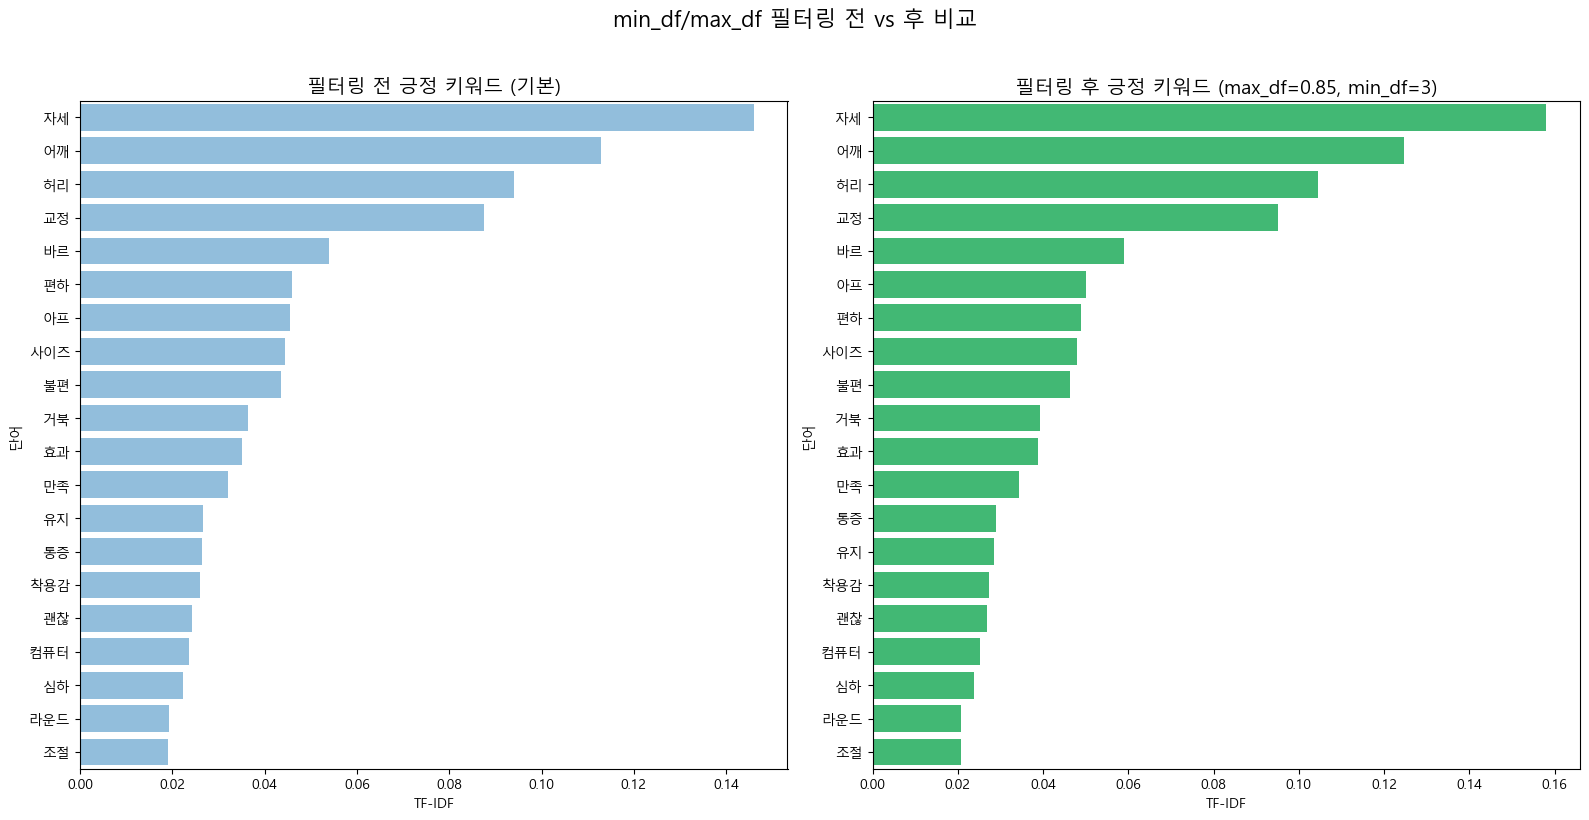


=> 필터링 후 모든 리뷰에 공통으로 등장하던 일반적인 단어가 제거되고,
   각 그룹을 더 잘 대표하는 차별적 키워드가 상위에 올라옵니다.


In [54]:
# ========================================
# 필터링 적용 전/후 긍정 키워드 비교 시각화
# ========================================

pos_filtered_kw = get_top_tfidf_keywords(tfidf_filtered_matrix, filtered_feature_names, pos_indices, top_n=20)
neg_filtered_kw = get_top_tfidf_keywords(tfidf_filtered_matrix, filtered_feature_names, neg_indices, top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

before_df = pd.DataFrame(pos_uni_keywords, columns=['단어', 'TF-IDF'])
sns.barplot(data=before_df, x='TF-IDF', y='단어', color='#85C1E9', ax=axes[0])
axes[0].set_title('필터링 전 긍정 키워드 (기본)', fontsize=14)

after_df = pd.DataFrame(pos_filtered_kw, columns=['단어', 'TF-IDF'])
sns.barplot(data=after_df, x='TF-IDF', y='단어', color='#2ecc71', ax=axes[1])
axes[1].set_title('필터링 후 긍정 키워드 (max_df=0.85, min_df=3)', fontsize=14)

plt.suptitle('min_df/max_df 필터링 전 vs 후 비교', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print()
print('=> 필터링 후 모든 리뷰에 공통으로 등장하던 일반적인 단어가 제거되고,')
print('   각 그룹을 더 잘 대표하는 차별적 키워드가 상위에 올라옵니다.')

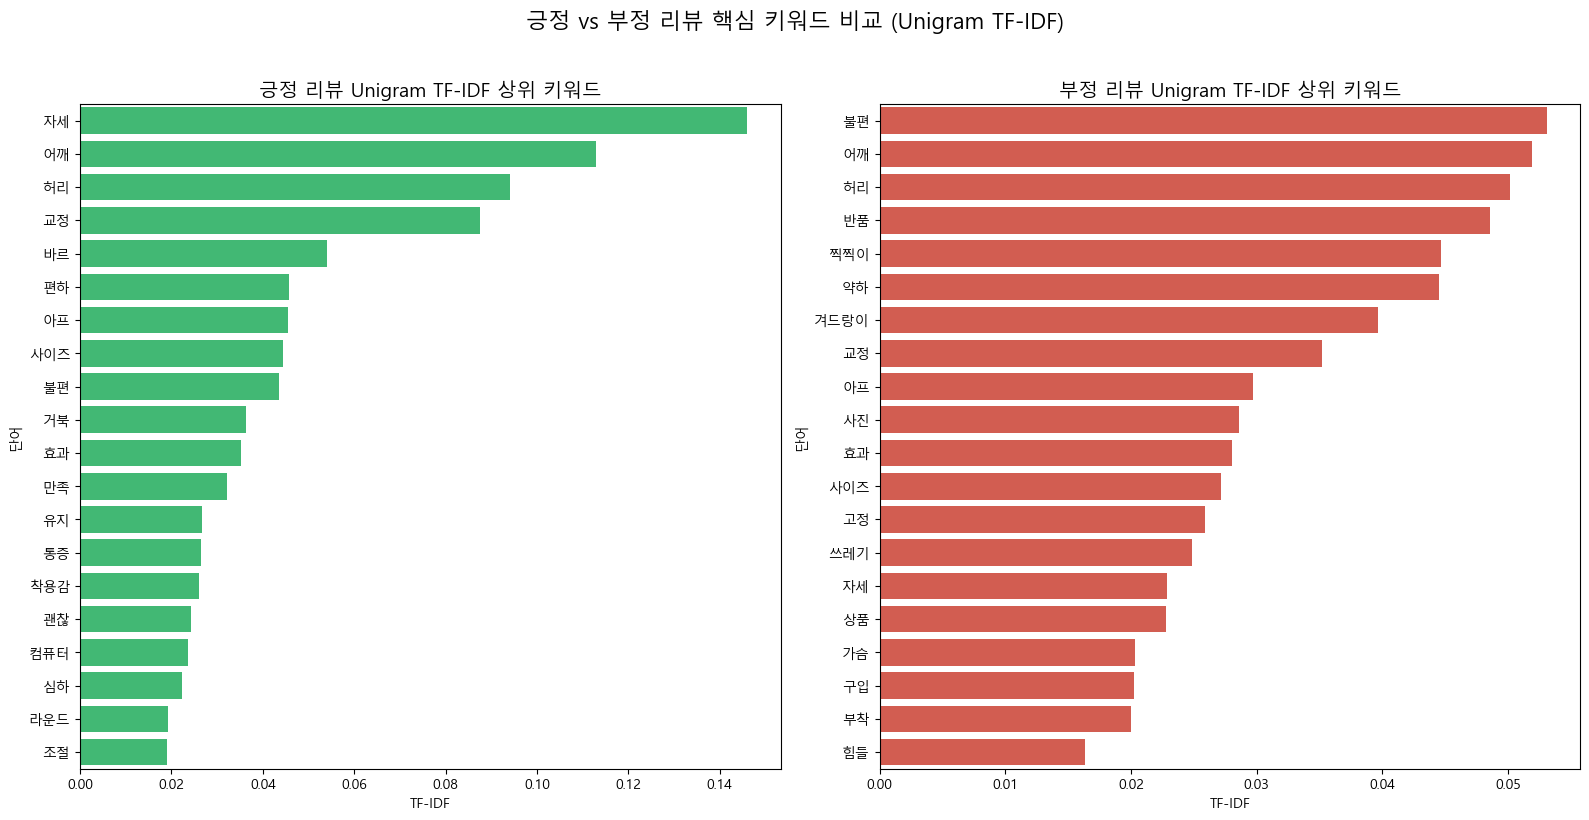

In [55]:
# ========================================
# Unigram TF-IDF 긍정 vs 부정 시각화
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

pos_uni_df = pd.DataFrame(pos_uni_keywords, columns=['단어', 'TF-IDF'])
sns.barplot(data=pos_uni_df, x='TF-IDF', y='단어', color='#2ecc71', ax=axes[0])
axes[0].set_title('긍정 리뷰 Unigram TF-IDF 상위 키워드', fontsize=14)

neg_uni_df = pd.DataFrame(neg_uni_keywords, columns=['단어', 'TF-IDF'])
sns.barplot(data=neg_uni_df, x='TF-IDF', y='단어', color='#e74c3c', ax=axes[1])
axes[1].set_title('부정 리뷰 Unigram TF-IDF 상위 키워드', fontsize=14)

plt.suptitle('긍정 vs 부정 리뷰 핵심 키워드 비교 (Unigram TF-IDF)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [56]:
# ========================================
# TF-IDF Bigram 벡터화
# ========================================

# ngram_range=(2,2) => Bigram (2단어 조합) 단위로 TF-IDF를 계산합니다
# max_features=3000 => 상위 3,000개 조합만 사용
tfidf_bi_vec = TfidfVectorizer(ngram_range=(2, 2), max_features=3000, max_df=0.85, min_df=3)
tfidf_bi_matrix = tfidf_bi_vec.fit_transform(df_sample['processed'])

bi_feature_names = tfidf_bi_vec.get_feature_names_out()

# --- Bigram TF-IDF 키워드 추출 ---
pos_bi_keywords = get_top_tfidf_keywords(tfidf_bi_matrix, bi_feature_names, pos_indices)
neg_bi_keywords = get_top_tfidf_keywords(tfidf_bi_matrix, bi_feature_names, neg_indices)


print(f'TF-IDF Bigram 행렬 크기: {tfidf_bi_matrix.shape}')
print()
print('=== Bigram TF-IDF 상위 키워드 ===')
display(pd.DataFrame({
    '긍정 키워드': [w for w, _ in pos_bi_keywords[:10]],
    '긍정 TF-IDF': [f'{s:.4f}' for _, s in pos_bi_keywords[:10]],
    '부정 키워드': [w for w, _ in neg_bi_keywords[:10]],
    '부정 TF-IDF': [f'{s:.4f}' for _, s in neg_bi_keywords[:10]],
}))

TF-IDF Bigram 행렬 크기: (1413, 1088)

=== Bigram TF-IDF 상위 키워드 ===


,긍정 키워드,긍정 TF-IDF,부정 키워드,부정 TF-IDF
0,자세 교정,0.0763,자세 교정,0.0341
1,바르 자세,0.0499,찍찍이 약하,0.0334
2,어깨 허리,0.0345,겨드랑이 아프,0.0237
3,허리 어깨,0.0323,어깨 허리,0.0203
4,어깨 자세,0.0300,허리 가슴,0.0192
5,자세 유지,0.0260,어깨 불편,0.0174
6,허리 아프,0.0260,사이즈 어깨,0.0153
7,자세 바르,0.0185,벨크로 부착,0.0140
8,어깨 아프,0.0183,허리 어깨,0.0133
9,자세 허리,0.0175,어깨 고정,0.0128


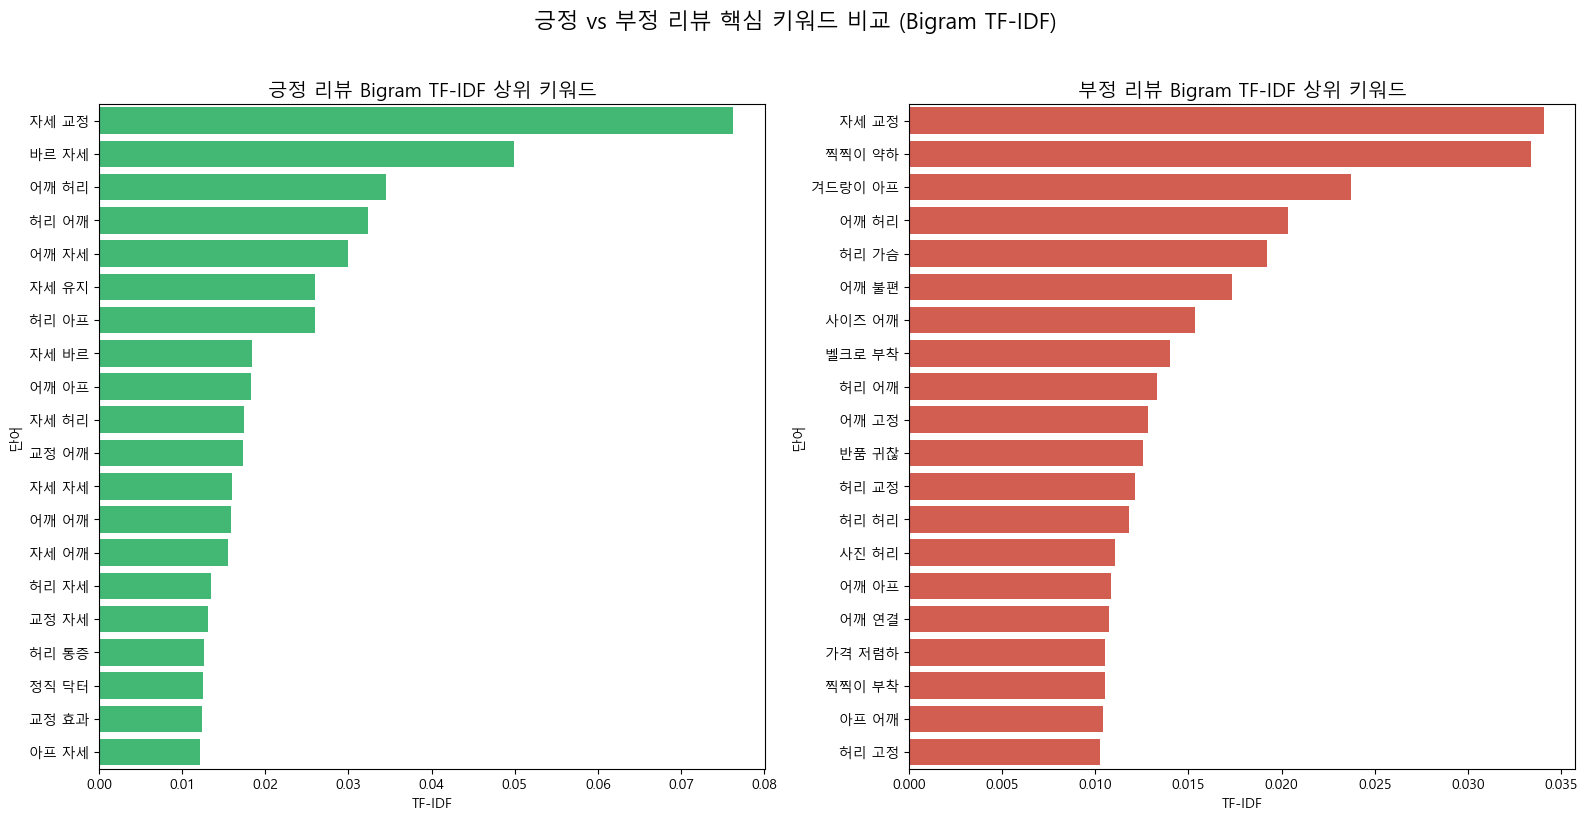

In [57]:
# ========================================
# Bigram TF-IDF 긍정 vs 부정 시각화
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

pos_bi_df = pd.DataFrame(pos_bi_keywords, columns=['단어', 'TF-IDF'])
sns.barplot(data=pos_bi_df, x='TF-IDF', y='단어', color='#2ecc71', ax=axes[0])
axes[0].set_title('긍정 리뷰 Bigram TF-IDF 상위 키워드', fontsize=14)

neg_bi_df = pd.DataFrame(neg_bi_keywords, columns=['단어', 'TF-IDF'])
sns.barplot(data=neg_bi_df, x='TF-IDF', y='단어', color='#e74c3c', ax=axes[1])
axes[1].set_title('부정 리뷰 Bigram TF-IDF 상위 키워드', fontsize=14)

plt.suptitle('긍정 vs 부정 리뷰 핵심 키워드 비교 (Bigram TF-IDF)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [58]:
# ========================================
# TF-IDF Unigram+Bigram (1,2) 통합 벡터화
# ========================================

# ngram_range=(1,2) => Unigram과 Bigram을 동시에 추출하여 TF-IDF 계산
# => 단일 단어의 중요도와 2단어 조합의 중요도를 함께 비교할 수 있습니다
tfidf_combined_vec = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, max_df=0.85, min_df=3)
tfidf_combined_matrix = tfidf_combined_vec.fit_transform(df_sample['processed'])

combined_feature_names = tfidf_combined_vec.get_feature_names_out()

# --- Unigram+Bigram TF-IDF 키워드 추출 ---
pos_combined_keywords = get_top_tfidf_keywords(tfidf_combined_matrix, combined_feature_names, pos_indices)
neg_combined_keywords = get_top_tfidf_keywords(tfidf_combined_matrix, combined_feature_names, neg_indices)


print(f'TF-IDF Unigram+Bigram 행렬 크기: {tfidf_combined_matrix.shape}')
print()
print('=== Unigram+Bigram TF-IDF 상위 키워드 ===')
display(pd.DataFrame({
    '긍정 키워드': [w for w, _ in pos_combined_keywords[:10]],
    '긍정 TF-IDF': [f'{s:.4f}' for _, s in pos_combined_keywords[:10]],
    '부정 키워드': [w for w, _ in neg_combined_keywords[:10]],
    '부정 TF-IDF': [f'{s:.4f}' for _, s in neg_combined_keywords[:10]],
}))


TF-IDF Unigram+Bigram 행렬 크기: (1413, 1750)

=== Unigram+Bigram TF-IDF 상위 키워드 ===


,긍정 키워드,긍정 TF-IDF,부정 키워드,부정 TF-IDF
0,자세,0.1081,찍찍이,0.0542
1,어깨,0.0865,반품,0.0522
2,허리,0.0729,불편,0.0439
3,교정,0.0652,약하,0.0427
4,자세 교정,0.0504,허리,0.0412
5,바르,0.0405,어깨,0.0407
6,아프,0.0344,겨드랑이,0.0344
7,사이즈,0.0339,사진,0.0329
8,바르 자세,0.0338,상품,0.0322
9,편하,0.0327,쓰레기,0.0305


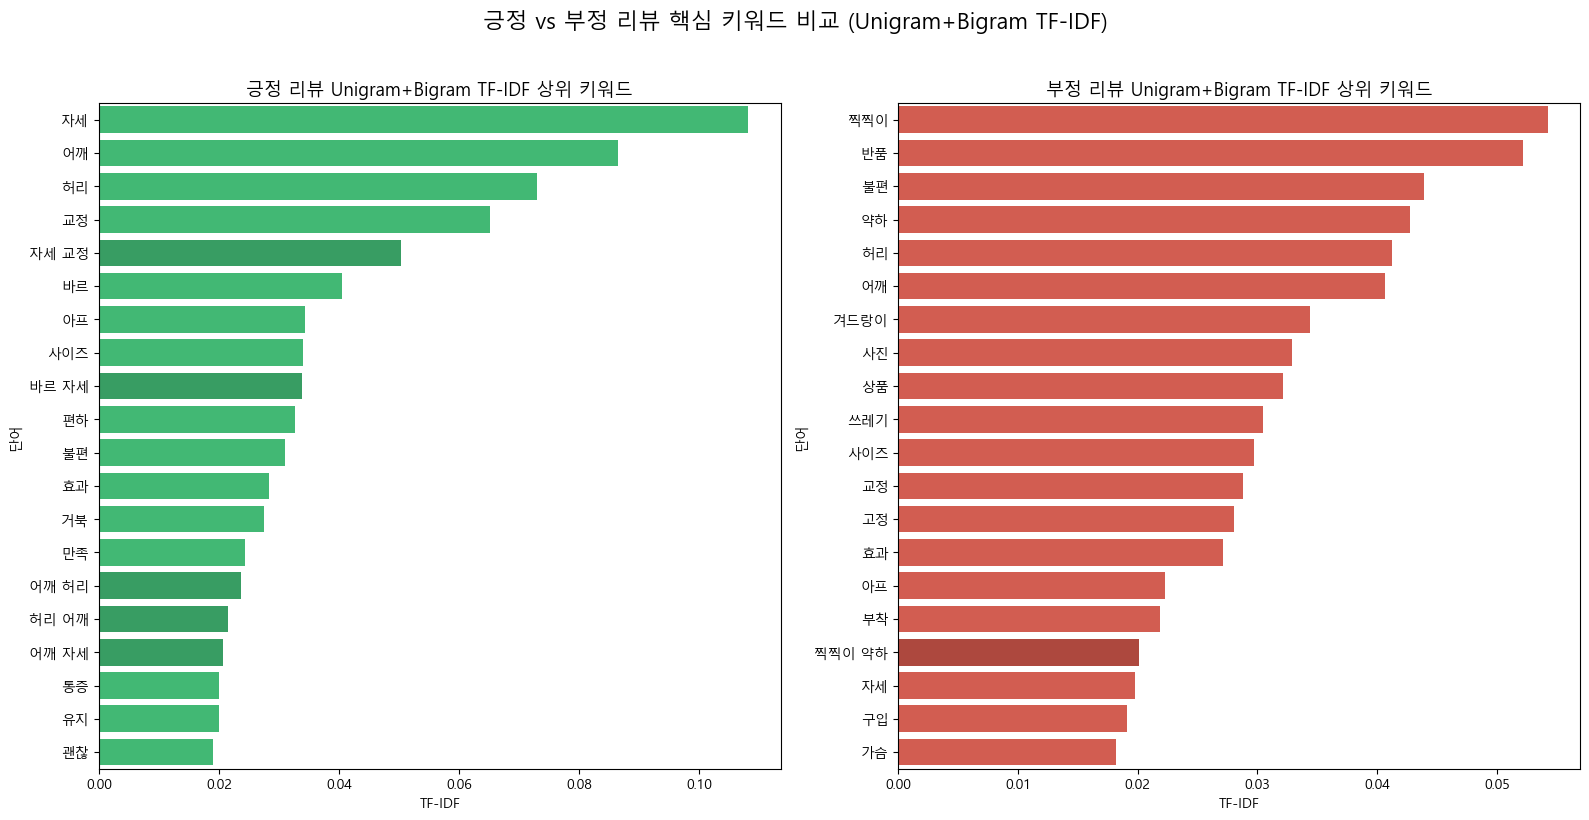

In [59]:
# ========================================
# Unigram+Bigram TF-IDF 긍정 vs 부정 시각화
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

pos_comb_df = pd.DataFrame(pos_combined_keywords, columns=['단어', 'TF-IDF'])
pos_comb_df['유형'] = pos_comb_df['단어'].apply(lambda x: 'Bigram' if ' ' in x else 'Unigram')
colors_pos = pos_comb_df['유형'].map({'Unigram': '#2ecc71', 'Bigram': '#27ae60'}).tolist()
sns.barplot(data=pos_comb_df, x='TF-IDF', y='단어', palette=colors_pos, ax=axes[0], hue='단어', legend=False)
axes[0].set_title('긍정 리뷰 Unigram+Bigram TF-IDF 상위 키워드', fontsize=13)

neg_comb_df = pd.DataFrame(neg_combined_keywords, columns=['단어', 'TF-IDF'])
neg_comb_df['유형'] = neg_comb_df['단어'].apply(lambda x: 'Bigram' if ' ' in x else 'Unigram')
colors_neg = neg_comb_df['유형'].map({'Unigram': '#e74c3c', 'Bigram': '#c0392b'}).tolist()
sns.barplot(data=neg_comb_df, x='TF-IDF', y='단어', palette=colors_neg, ax=axes[1], hue='단어', legend=False)
axes[1].set_title('부정 리뷰 Unigram+Bigram TF-IDF 상위 키워드', fontsize=13)

plt.suptitle('긍정 vs 부정 리뷰 핵심 키워드 비교 (Unigram+Bigram TF-IDF)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# Counter Vectorizer
# Tf-idf Vectorizer

# 공통점과 차이점
- 공통점 : 단어의 빈도와 관련이 있다!
- 차이점 : 
Counter : 한 문서 내에서 단어의빈도를 체크한다
Tf-idf : 개별 문서의 빈도를 세는 것과 문서 전체에서 나온 단어의 희귀도를 반영한다 (tf-idf는 희소행렬로 만든다)

#### 긍정/부정 고유 키워드 추출

위의 TF-IDF 결과를 보면 '어깨', '자세', '교정' 같은 단어가 긍정/부정 양쪽에 모두 등장합니다.
이런 **공통 키워드** 는 감성을 구분하는 데 도움이 되지 않습니다.

**각 그룹만의 고유 키워드** 를 뽑으려면 어떻게 해야 할까요?

| 방법 | 계산 | 의미 |
|------|------|------|
| TF-IDF 차이 | 긍정 평균 TF-IDF **-** 부정 평균 TF-IDF | 단순하고 직관적 |

**해석 방법:**

| 차이 값 | 의미 |
|---------|------|
| 큰 양수 | 긍정 리뷰에서만 자주 등장하는 **긍정 고유 키워드** |
| 큰 음수 | 부정 리뷰에서만 자주 등장하는 **부정 고유 키워드** |
| 0 근처 | 양쪽 모두 비슷하게 쓰이는 공통 단어 (구분력 없음) |

In [65]:
# ========================================
# 긍정/부정 고유 키워드 추출 (TF-IDF 차이 분석)
# ========================================

# Step 1: 긍정/부정 그룹별 평균 TF-IDF 벡터 계산
pos_mean = tfidf_combined_matrix[pos_indices].mean(axis=0).A1 
neg_mean = tfidf_combined_matrix[neg_indices].mean(axis=0).A1 

print('=== Step 1: 그룹별 평균 TF-IDF 벡터 ===')
print(f'긍정 평균 벡터 크기: {pos_mean.shape}')
print(f'부정 평균 벡터 크기: {neg_mean.shape}')

sample_df = pd.DataFrame({
    '단어':tfidf_combined_vec.get_feature_names_out()[:10],
    '긍정 평균 TF-IDF': pos_mean[:10],
    '부정 평균 TF-IDF': neg_mean[:10],
})

display(sample_df)

=== Step 1: 그룹별 평균 TF-IDF 벡터 ===
긍정 평균 벡터 크기: (1750,)
부정 평균 벡터 크기: (1750,)


,단어,긍정 평균 TF-IDF,부정 평균 TF-IDF
0,가격,0.011927,0.012377
1,가격 괜찮,0.002291,0.000000
2,가격 대비,0.002632,0.001511
3,가격 만족,0.001175,0.000000
4,가격 부담,0.001450,0.000000
5,가격 저렴하,0.001883,0.003090
6,가격 퀄리티,0.000802,0.000000
7,가격 합리,0.000635,0.000744
8,가격대,0.001475,0.005346
9,가능,0.014264,0.002378


In [66]:
# Step 2: 차이 계산 (긍정 - 부정)
# diff > 0: 긍정에서 더 많이 사용된 단어
# diff < 0: 부정에서 더 많이 사용된 단어
diff_mean = pos_mean - neg_mean

sample_df = pd.DataFrame({
    '단어':tfidf_combined_vec.get_feature_names_out()[:10],
    '긍정 평균 TF-IDF': pos_mean[:10],
    '부정 평균 TF-IDF': neg_mean[:10],
    '차이 TF-IDF' : diff_mean[:10]
})
display(sample_df)

,단어,긍정 평균 TF-IDF,부정 평균 TF-IDF,차이 TF-IDF
0,가격,0.011927,0.012377,-0.000450
1,가격 괜찮,0.002291,0.000000,0.002291
2,가격 대비,0.002632,0.001511,0.001122
3,가격 만족,0.001175,0.000000,0.001175
4,가격 부담,0.001450,0.000000,0.001450
5,가격 저렴하,0.001883,0.003090,-0.001208
6,가격 퀄리티,0.000802,0.000000,0.000802
7,가격 합리,0.000635,0.000744,-0.000108
8,가격대,0.001475,0.005346,-0.003870
9,가능,0.014264,0.002378,0.011886


# 오답 용사왕!!! 
# 질문을 많이 적극적으로 하시면 포인트 2배 찬스!!

In [67]:
# Step 3: 고유 키워드 상위 20개 추출

# 긍정 고유 키워드: diff를 내림차순 정렬, 양수인 것만 추출
pos_unique_idx = diff_mean.argsort()[::-1]  # argsort 값으로 정렬하되 인덱스를 반환
pos_unique_idx = pos_unique_idx[diff_mean[pos_unique_idx] > 0] # 값이 양수인 것만

# 부정 고유 키워드: diff를 오름차순 정렬, 음수인 것만 추출 (절댓값으로 변환)
neg_unique_idx = diff_mean.argsort()  # argsort 값으로 정렬하되 인덱스를 반환
neg_unique_idx = neg_unique_idx[diff_mean[neg_unique_idx] < 0] # 값이 양수인 것만


print('=== Step 3: 최종 고유 키워드 ===')
print()
pos_unique_keywords = [(combined_feature_names[i], diff_mean[i]) for i in pos_unique_idx]
neg_unique_keywords = [(combined_feature_names[i], diff_mean[i]) for i in neg_unique_idx]

print(f'긍정 고유 키워드: 총 {len(pos_unique_keywords):,}개 (상위 10개):')
for word, score in pos_unique_keywords[:10]:
    print(f'  {word}: {score:.4f}')
print()
print(f'부정 고유 키워드: 총 {len(neg_unique_keywords):,}개 (상위 10개):')
for word, score in neg_unique_keywords[:10]:
    print(f'  {word}: {score:.4f}')

=== Step 3: 최종 고유 키워드 ===

긍정 고유 키워드: 총 1,479개 (상위 10개):
  자세: 0.0884
  어깨: 0.0458
  바르: 0.0373
  교정: 0.0364
  자세 교정: 0.0325
  허리: 0.0316
  바르 자세: 0.0303
  편하: 0.0253
  만족: 0.0235
  어깨 자세: 0.0202

부정 고유 키워드: 총 271개 (상위 10개):
  반품: -0.0508
  찍찍이: -0.0488
  약하: -0.0401
  쓰레기: -0.0305
  사진: -0.0297
  상품: -0.0272
  겨드랑이: -0.0260
  부착: -0.0202
  찍찍이 약하: -0.0199
  중국: -0.0172


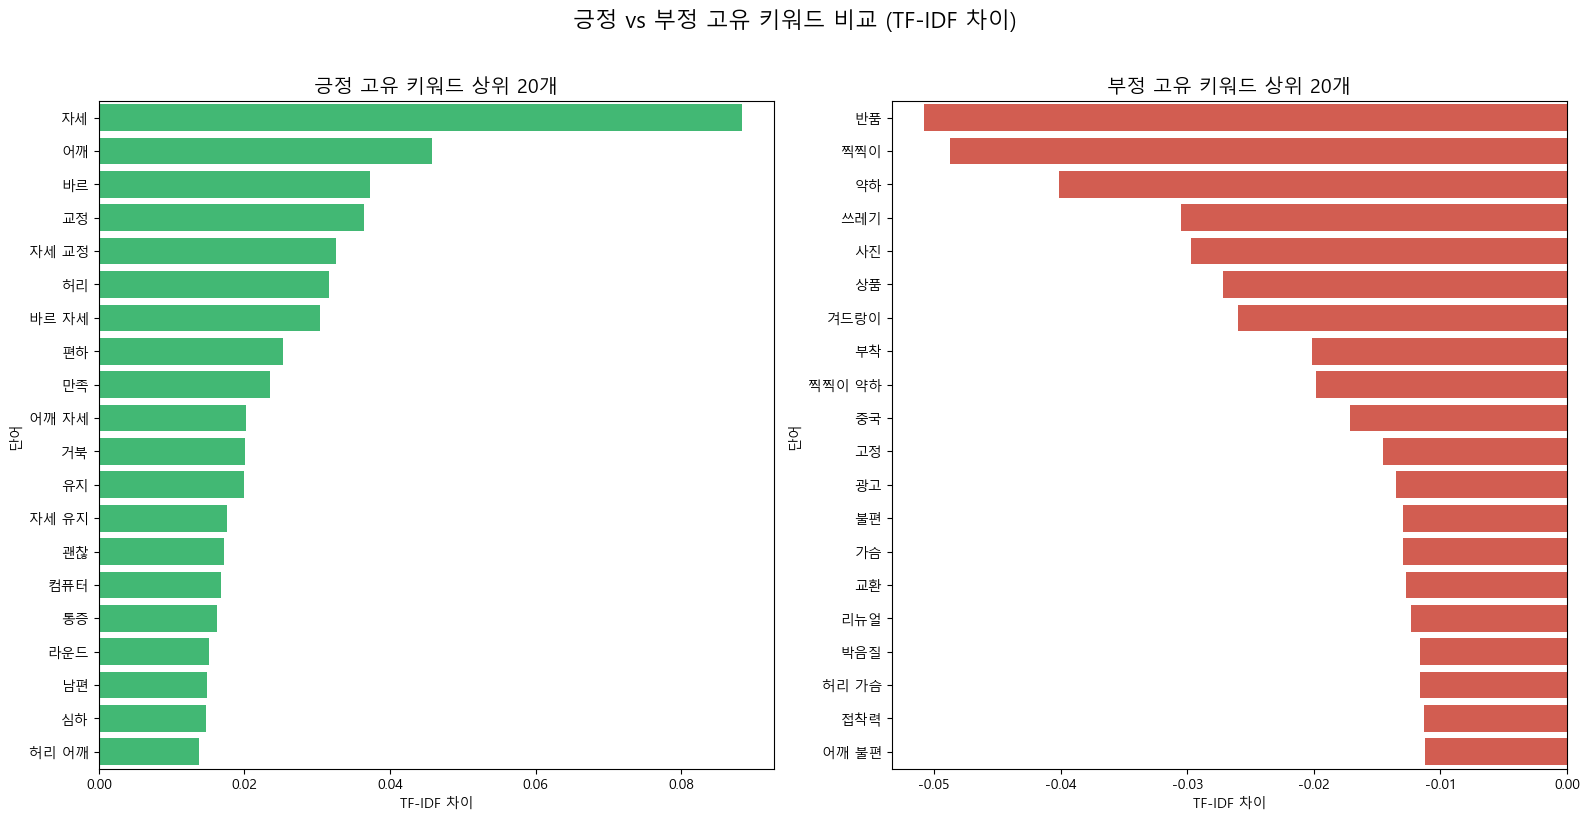

In [68]:
# ========================================
# 긍정/부정 고유 키워드 시각화
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

pos_diff_df = pd.DataFrame(pos_unique_keywords[:20], columns=['단어', 'TF-IDF 차이'])
sns.barplot(data=pos_diff_df, x='TF-IDF 차이', y='단어', color='#2ecc71', ax=axes[0])
axes[0].set_title('긍정 고유 키워드 상위 20개', fontsize=14)

neg_diff_df = pd.DataFrame(neg_unique_keywords[:20], columns=['단어', 'TF-IDF 차이'])
sns.barplot(data=neg_diff_df, x='TF-IDF 차이', y='단어', color='#e74c3c', ax=axes[1])
axes[1].set_title('부정 고유 키워드 상위 20개', fontsize=14)

plt.suptitle('긍정 vs 부정 고유 키워드 비교 (TF-IDF 차이)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 5. 워드 클라우드 시각화

**워드클라우드(Word Cloud)** 를 만들어봅시다.

- 텍스트 데이터에서 단어의 빈도나 중요도를 **글자 크기** 로 시각화하는 방법입니다
- 빈도가 높을수록 => 글자가 크게 표시됩니다
- 한눈에 핵심 키워드를 파악할 수 있어 보고서나 발표 자료에 자주 활용됩니다

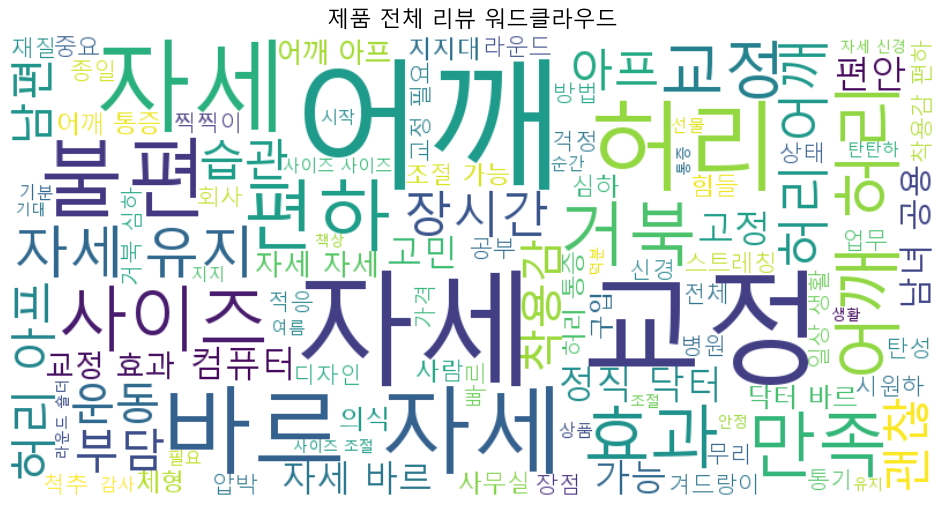

In [69]:
# ========================================
# 전체 리뷰 워드클라우드
# ========================================

import platform
if platform.system() == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':
    font_path = '/System/Library/Fonts/AppleSDGothicNeo.ttc'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

all_text = ' '.join(df_sample['processed'])

wc = WordCloud(
    font_path=font_path, 
    width=800, height=400,
    background_color='white', max_words=100, colormap='viridis'
)
wc.generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('제품 전체 리뷰 워드클라우드', fontsize=16)
plt.show()


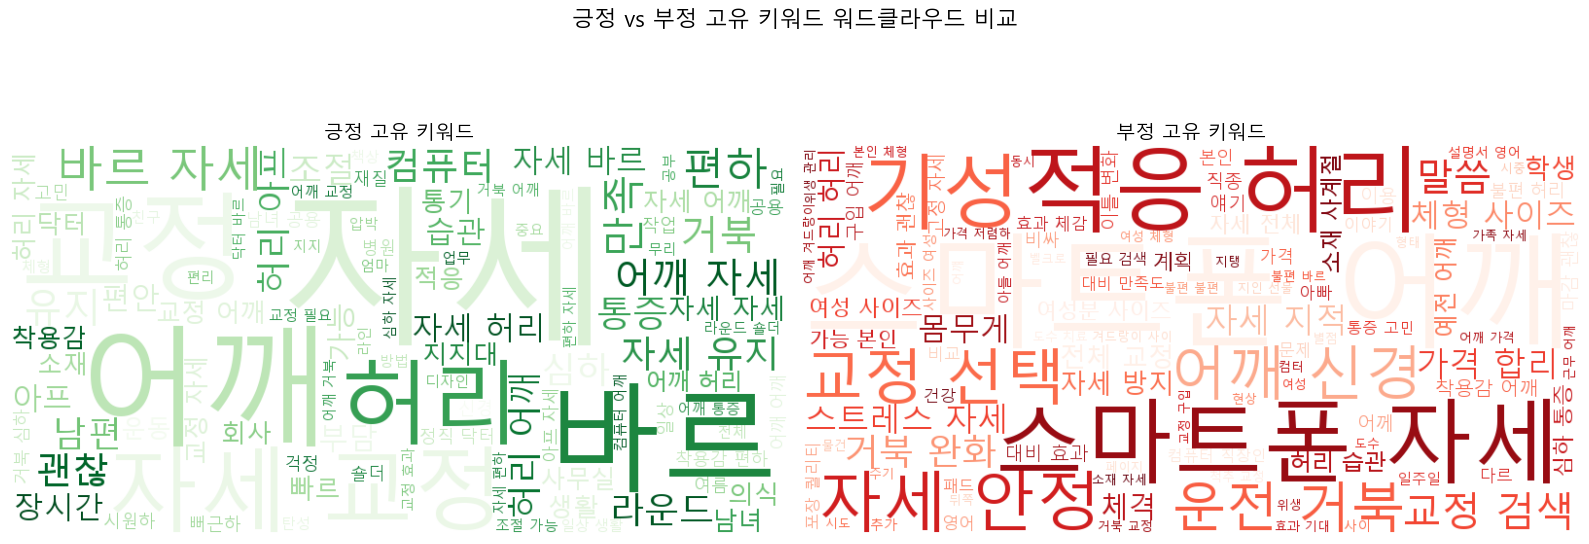

In [70]:
# ========================================
# 긍정 vs 부정 고유 키워드 워드클라우드 비교
# ========================================

pos_unique_dict = {word: score for word, score in pos_unique_keywords}
neg_unique_dict = {word: score for word, score in neg_unique_keywords}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(
    font_path=font_path, width=800, height=400,
    background_color='white', max_words=100,
    min_font_size=8, colormap='Greens'
).generate_from_frequencies(pos_unique_dict)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('긍정 고유 키워드', fontsize=14)

wc_neg = WordCloud(
    font_path=font_path, width=800, height=400,
    background_color='white', max_words=100,
    min_font_size=8, colormap='Reds'
).generate_from_frequencies(neg_unique_dict)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('부정 고유 키워드', fontsize=14)

plt.suptitle('긍정 vs 부정 고유 키워드 워드클라우드 비교', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


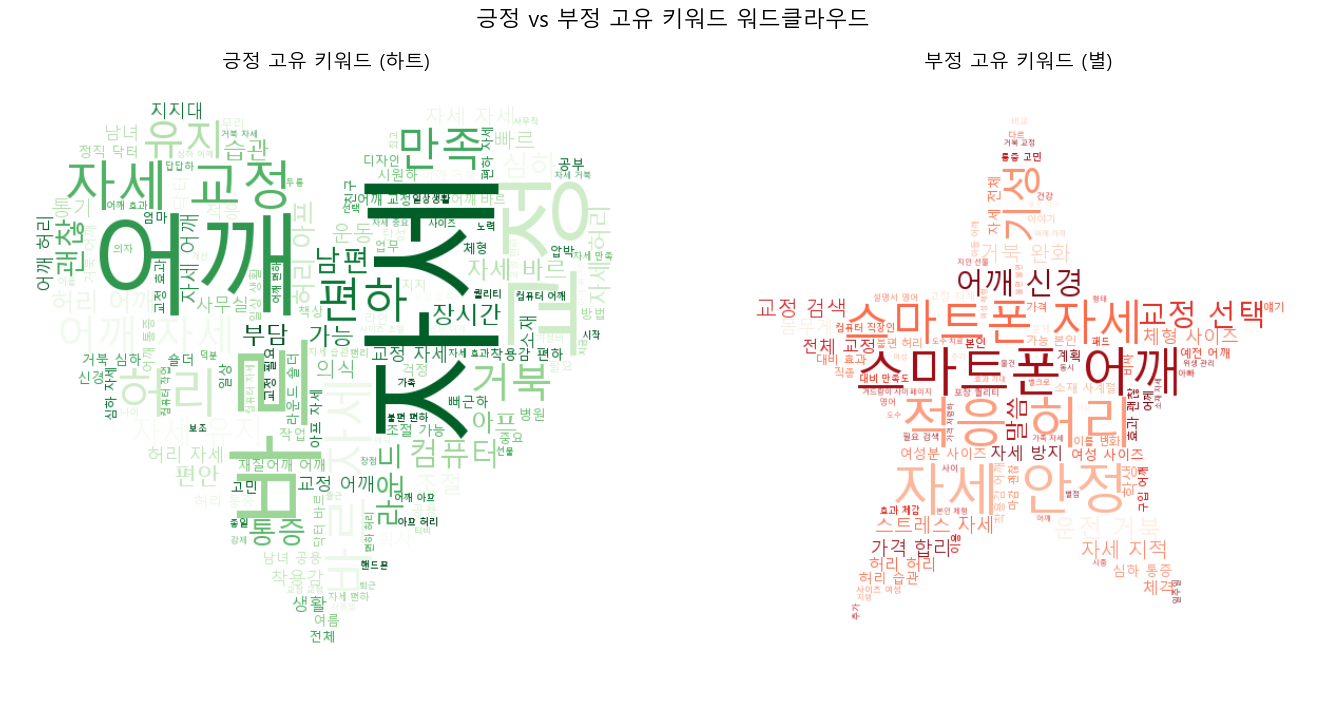

In [71]:
# ========================================
# 모양 마스크를 활용한 워드클라우드
# ========================================

from PIL import Image

# 이미지 3채널 가로 x 세로 픽셀마다 (R,G,B)
# .convert('L') : 흑백 1채널로 변환! 가로 x 세로 마다 1개의 값이 있음
pos_mask = np.array(Image.open('images/mask_heart.png').convert('L'))
neg_mask = np.array(Image.open('images/mask_star.png').convert('L'))

pos_unique_dict = {word: score for word, score in pos_unique_keywords}
neg_unique_dict = {word: score for word, score in neg_unique_keywords}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

wc_pos = WordCloud(
    font_path=font_path, mask=pos_mask,
    background_color='white', max_words=150,
    min_font_size=6, colormap='Greens',
).generate_from_frequencies(pos_unique_dict)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('긍정 고유 키워드 (하트)', fontsize=14)

wc_neg = WordCloud(
    font_path=font_path, mask=neg_mask,
    background_color='white', max_words=150,
    min_font_size=6, colormap='Reds',
).generate_from_frequencies(neg_unique_dict)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('부정 고유 키워드 (별)', fontsize=14)

plt.suptitle('긍정 vs 부정 고유 키워드 워드클라우드', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


StyleCloud 라이브러리~! -> Seaborn 워드클라우드를 더 이쁘게 표현해줄 수 있는 (모양+색감)라이브러리 ==> 라이브러리 업데이트 잘 안됐음! ==> 최신 파이썬 및 다른 라이브러리랑 호환이 잘 안되서 --> 

StyleCloud 라이브리를 이용하려면 python 및 기타 라이브러리 버전을 맞춰야함!

#### 하나의 워드클라우드에 긍정/부정 색상 구분하기

앞에서는 긍정·부정 워드클라우드를 **따로** 만들었습니다.  
이번에는 **하나의 워드클라우드 안에서** 긍정 단어는 초록, 부정 단어는 빨강으로 색칠해봅시다.

- `recolor(color_func=...)` 를 사용하면 단어별로 색상을 직접 지정할 수 있습니다

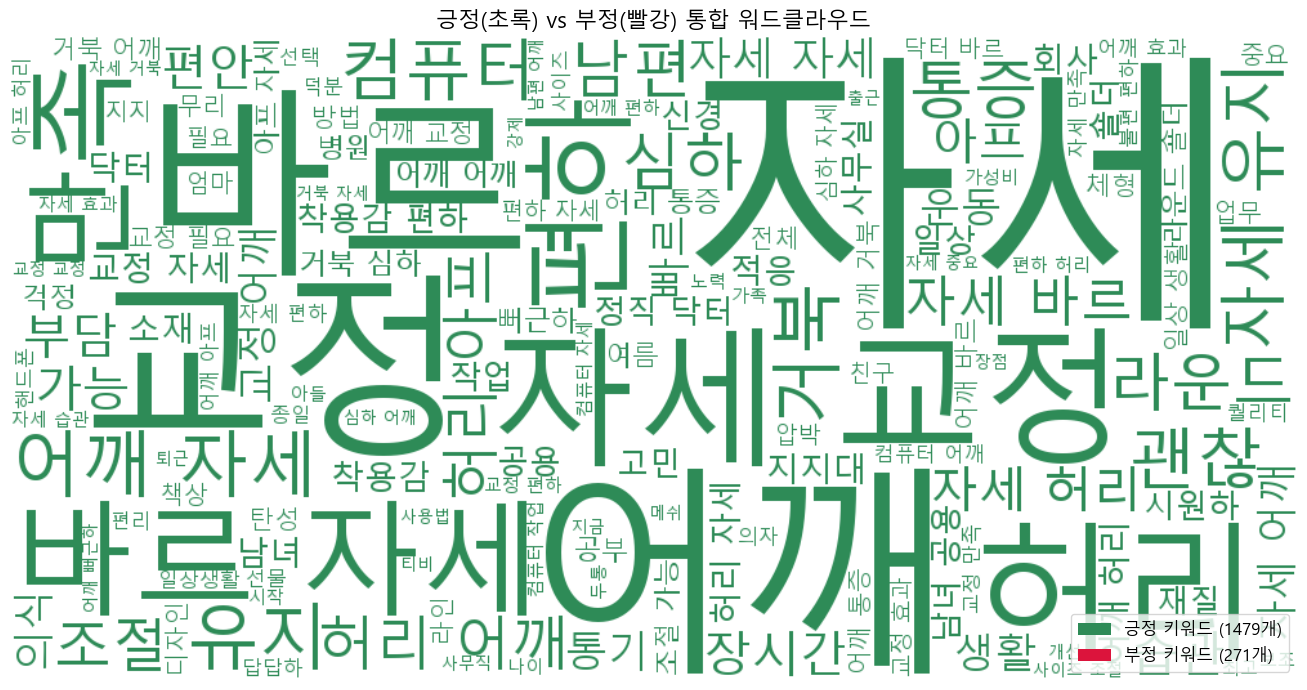

긍정 키워드 수: 1479개
부정 키워드 수: 271개
전체 키워드 수: 1750개


In [73]:
# ========================================
# 긍정/부정 통합 워드클라우드 (색상 구분)
# ========================================

# 긍정 + 부정 고유 키워드를 하나의 딕셔너리로 합치기
pos_unique_dict = {word: score for word, score in pos_unique_keywords}
neg_unique_dict = {word: score for word, score in neg_unique_keywords}

combined_dict = {}
combined_dict.update(pos_unique_dict)
combined_dict.update(neg_unique_dict)

# 긍정/부정 단어 집합 정의 (색상 분류용)
positive_words = set(pos_unique_dict.keys())
negative_words = set(neg_unique_dict.keys())

# 커스텀 색상 함수: 단어에 따라 색상 반환
def sentiment_color(word, **kwargs):
    if word in positive_words:
        return "#2E8B57"   # 초록 (긍정)
    elif word in negative_words:
        return "#DC143C"   # 빨강 (부정)
    else:
        return "#999999"   # 회색 (중립)

# 통합 워드클라우드 생성
wc_combined = WordCloud(
    font_path=font_path,
    width=1000, height=500,
    background_color="white",
    max_words=150,
    min_font_size=8
)
wc_combined.generate_from_frequencies(combined_dict)

# 감성별 색상 적용
wc_combined.recolor(color_func=sentiment_color)

# 시각화
plt.figure(figsize=(14, 7))
plt.imshow(wc_combined, interpolation="bilinear")
plt.axis("off")
plt.title("긍정(초록) vs 부정(빨강) 통합 워드클라우드", fontsize=16)

# 범례 추가
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2E8B57", label=f"긍정 키워드 ({len(positive_words)}개)"),
    Patch(facecolor="#DC143C", label=f"부정 키워드 ({len(negative_words)}개)")
]
plt.legend(handles=legend_elements, loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()

print(f"긍정 키워드 수: {len(positive_words)}개")
print(f"부정 키워드 수: {len(negative_words)}개")
print(f"전체 키워드 수: {len(combined_dict)}개")

### 6. 별점별 키워드 변화 추적

지금까지는 별점 4~5를 긍정, 1~3을 부정으로 **이분법** 으로 나눴습니다.
하지만 별점 1점과 3점은 같은 "부정"이지만 불만의 정도가 다릅니다.

**별점별로 키워드가 어떻게 달라지는지** 세밀하게 추적해봅시다.

| 별점 | 예상되는 특징 |
|------|-------------|
| 1점 | 강한 불만, 결함, 반품/환불 관련 키워드 |
| 2점 | 기대 이하, 부분적 불만 |
| 3점 | 보통, 장단점 혼재 |
| 4점 | 대체로 만족, 사소한 아쉬움 |
| 5점 | 강한 만족, 재구매/추천 키워드 |

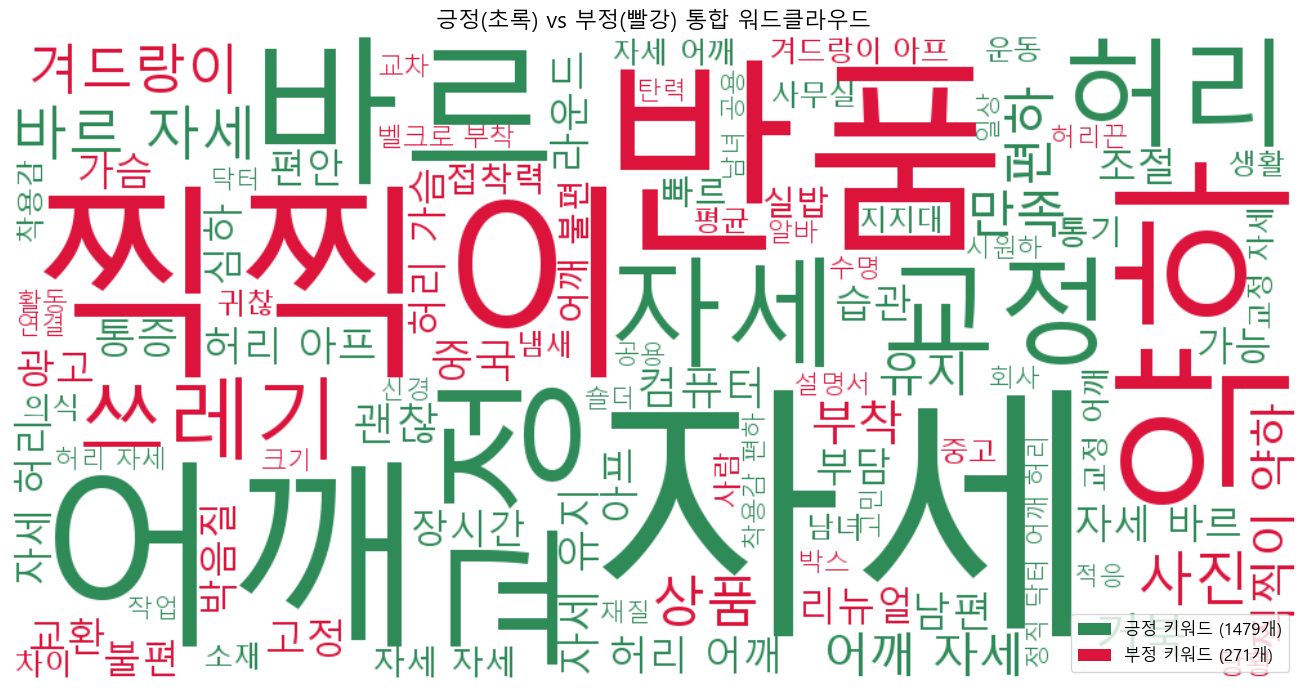

긍정 키워드 수: 1479개
부정 키워드 수: 271개
전체 키워드 수: 1750개


In [77]:
# ========================================
# 긍정/부정 통합 워드클라우드 (색상 구분)
# ========================================

# 긍정/부정 고유 키워드 상위 30개씩 추출
pos_top30 = {word: score for word, score in pos_unique_keywords}
neg_top30 = {word: abs(score) for word, score in neg_unique_keywords}  # 음수 → 절댓값 변환!

# 하나의 딕셔너리로 합치기
combined_dict = {}
combined_dict.update(pos_top30)
combined_dict.update(neg_top30)

# 긍정/부정 단어 집합 정의 (색상 분류용)
positive_words = set(pos_top30.keys())
negative_words = set(neg_top30.keys())

# 커스텀 색상 함수: 단어에 따라 색상 반환
def sentiment_color(word, **kwargs):
    if word in positive_words:
        return "#2E8B57"   # 초록 (긍정)
    elif word in negative_words:
        return "#DC143C"   # 빨강 (부정)
    else:
        return "#999999"   # 회색 (중립)

# 통합 워드클라우드 생성
wc_combined = WordCloud(
    font_path=font_path,
    width=1000, height=500,
    background_color="white",
    max_words=100,
    min_font_size=8
)
wc_combined.generate_from_frequencies(combined_dict)

# 감성별 색상 적용
wc_combined.recolor(color_func=sentiment_color)

# 시각화
from matplotlib.patches import Patch

plt.figure(figsize=(14, 7))
plt.imshow(wc_combined, interpolation="bilinear")
plt.axis("off")
plt.title("긍정(초록) vs 부정(빨강) 통합 워드클라우드", fontsize=16)

# 범례 추가
legend_elements = [
    Patch(facecolor="#2E8B57", label=f"긍정 키워드 ({len(positive_words)}개)"),
    Patch(facecolor="#DC143C", label=f"부정 키워드 ({len(negative_words)}개)")
]
plt.legend(handles=legend_elements, loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()

print(f"긍정 키워드 수: {len(positive_words)}개")
print(f"부정 키워드 수: {len(negative_words)}개")
print(f"전체 키워드 수: {len(combined_dict)}개")

In [ ]:
# ========================================
# 별점별 키워드 히트맵 시각화
# ========================================

# 모든 별점의 상위 키워드를 합쳐서 중복 없는 리스트 만들기
all_keywords = []
seen = set()
for rating in sorted(rating_keywords.keys()):
    for word, _ in rating_keywords[rating]:
        if word not in seen:
            all_keywords.append(word)
            seen.add(word)

feature_list = list(filtered_feature_names)

heatmap_df = pd.DataFrame({
    f'{rating}점': pd.Series(
        tfidf_filtered_matrix[df_sample[df_sample['rating'] == rating].index.tolist()].mean(axis=0).A1,
        index=feature_list
    ).reindex(all_keywords, fill_value=0.0)
    for rating in sorted(rating_keywords)
}).T

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    heatmap_df, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': 'TF-IDF 평균'}, ax=ax
)
ax.set_title('별점별 키워드 TF-IDF 히트맵', fontsize=16)
ax.set_xlabel('키워드', fontsize=12)
ax.set_ylabel('별점', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 7. 동시출현(Co-occurrence) 분석

지금까지 분석한 N-gram은 **바로 옆에 붙어 있는 단어 조합** 만 포착합니다.
하지만 실제 리뷰에서는 "어깨"와 "편하다"가 떨어져 있어도 **같은 리뷰 안에서 함께 언급** 되는 경우가 많습니다.

**동시출현(Co-occurrence)** 분석은 이런 관계를 찾아줍니다:

| | N-gram | 동시출현 |
|---|---|---|
| **조건** | 단어가 바로 옆에 연속으로 등장 | 같은 문서(리뷰) 안에 함께 등장 |
| **예시** | "어깨 통증" (바로 붙어야 함) | "어깨...편하다" (떨어져 있어도 OK) |
| **포착** | 구문(phrase) 패턴 | 개념 간 관계(association) |
| **시각화** | 막대 그래프 | **네트워크 그래프** |

**동시출현 행렬 만드는 법:**
- `CountVectorizer(binary=True)`로 DTM을 만듭니다 (등장 여부만 0/1로 기록)
- `DTM.T @ DTM` = 단어 x 단어 동시출현 행렬 (**함께 등장한 리뷰 수**)

> **왜 `binary=True`인가?** 등장 횟수(기본값)를 사용하면 한 리뷰에서 특정 단어가 여러 번 반복될 때 값이 과대 추정됩니다.
> `binary=True`로 설정하면 DTM 값이 0 또는 1이 되어, `DTM.T @ DTM`의 결과가 정확히 **"두 단어가 함께 등장한 리뷰의 수"** 가 됩니다.

![동시출현 행렬 설명](images/1_co_occurrence_matrix_explanation.png)

**@ 연산은 어떻게 동작할까?**
- DTM.T의 행(단어A가 등장한 리뷰)과 DTM의 열(단어B가 등장한 리뷰)을 곱해서 합산합니다
- 두 단어가 **모두 등장한 리뷰** 에서만 1x1=1이 되어 카운트됩니다

![@ 연산 설명](images/1_matrix_multiplication_explanation.png)

In [ ]:
# ========================================
# 동시출현 행렬 생성 (DTM 기반)
# ========================================

# CountVectorizer로 DTM 생성 (max_df=0.85, min_df=3)
# binary = True 문서(리뷰)하나당 출현횟수가 많아도 True(1)표현한다. 
# "자세가 좋지 않다. 자세를 바르게해야한다." ==> 자세 단어가 1로 
co_vec = CountVectorizer(ngram_range=(1,1), max_df=0.85, min_df=3, binary=True) 
co_dtm = co_vec.fit_transform(df_sample['processed'])
co_words = co_vec.get_feature_names_out()

# 동시출현 행렬 계산: DTM.T @ DTM
co_matrix = co_dtm.T @ co_dtm

# 대각선(자기 자신)을 0으로 설정
co_dtm.setdiag(0) #대각선(자기 자신의 단어 값)은 0으로 설정
co_array = co_matrix.toarray() #2x2 => 1차원 배열

print(f'동시출현 행렬 크기: {co_array.shape}')
print()

# 상위 동시출현 쌍 추출 (상삼각 행렬만 순회하여 중복 방지)
co_pairs = []
for i in range(len(co_words)):
    for j in range(i + 1, len(co_words)):
        if co_array[i, j] > 0:
            co_pairs.append((co_words[i], co_words[j], co_array[i, j]))

co_pairs.sort(key=lambda x: x[2], reverse=True)

co_df = pd.DataFrame(co_pairs[:20], columns=['단어1', '단어2', '동시출현 횟수'])
co_df['동시출현 횟수'] = co_df['동시출현 횟수'].astype(int)
print('=== 동시출현 상위 20개 단어 쌍 ===')
display(co_df)


In [ ]:
# ========================================
# 동시출현 상위 단어 쌍 막대 그래프
# ========================================

top_co_pairs = co_pairs[:20]
pair_labels = [f'{w1} + {w2}' for w1, w2, _ in top_co_pairs]
pair_counts = [int(count) for _, _, count in top_co_pairs]

fig, ax = plt.subplots(figsize=(10, 8))
co_df = pd.DataFrame({'단어 쌍': pair_labels, '동시출현 횟수': pair_counts})
sns.barplot(data=co_df, x='동시출현 횟수', y='단어 쌍', color='mediumpurple', ax=ax)
ax.set_title('동시출현 상위 20개 단어 쌍', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ========================================
# 동시출현 네트워크 시각화 함수 정의 + 전체 네트워크 생성
# ========================================

from pyvis.network import Network


def create_network_graph(pairs, filename, title='', top_n=30,
                         node_color='#3498db', height='700px'):
    """
    동시출현 쌍 리스트를 받아서 pyvis 인터랙티브 네트워크 HTML을 생성합니다.
    
    Parameters
    ----------
    pairs : list of (str, str, int)
        (단어1, 단어2, 동시출현 횟수) 형태의 리스트
    filename : str
        저장할 HTML 파일명 (예: 'co_occurrence_network.html')
    title : str
        HTML 상단에 표시할 제목 (기본값: 빈 문자열)
    top_n : int
        상위 몇 개의 쌍을 시각화할지 (기본값: 30)
    node_color : str
        노드 색상 hex 코드 (기본값: '#3498db' 파란색)
    height : str
        캔버스 높이 (기본값: '700px')
    """
    G = nx.Graph()
    for w1, w2, count in pairs[:top_n]:
        G.add_edge(w1, w2, weight=int(count))

    net = Network(height=height, width='100%', bgcolor='#ffffff',
                  font_color='#333333')

    # 노드 크기 계산 (min-max 정규화)
    node_weights = {}
    for node in G.nodes():
        node_weights[node] = sum(d['weight'] for _, _, d in G.edges(node, data=True))

    max_nw = max(node_weights.values())
    min_nw = min(node_weights.values())
    nw_range = max_nw - min_nw if max_nw != min_nw else 1

    for node in G.nodes():
        normalized_size = 15 + (node_weights[node] - min_nw) / nw_range * 35
        net.add_node(node, label=node,
                     size=normalized_size,
                     color=node_color,
                     font={'size': 16, 'face': 'Malgun Gothic'})

    max_ew = max(d['weight'] for _, _, d in G.edges(data=True))

    for u, v, d in G.edges(data=True):
        w = d['weight']
        net.add_edge(u, v,
                     width=1 + (w / max_ew) * 7,
                     color={'color': '#aaaaaa', 'opacity': 0.6},
                     title=f'{u} + {v}: {w}회')

    net.set_options('''
    {
      "physics": {
        "forceAtlas2Based": {
          "gravitationalConstant": -80,
          "centralGravity": 0.01,
          "springLength": 150,
          "springConstant": 0.05
        },
        "solver": "forceAtlas2Based",
        "stabilization": {"iterations": 200}
      },
      "interaction": {
        "hover": true,
        "zoomView": true,
        "dragNodes": true
      }
    }
    ''')

    net.save_graph(filename)

    if title:
        with open(filename, 'r', encoding='utf-8') as f:
            html = f.read()
        title_tag = f'<h2 style="text-align:center; font-family:Malgun Gothic; color:#333;">{title}</h2>'
        html = html.replace('<body>', f'<body>\n{title_tag}', 1)
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(html)

    print(f'=> {filename} 저장 완료' + (f' ({title})' if title else ''))


# 전체 동시출현 네트워크 생성
create_network_graph(
    pairs=co_pairs,
    filename='co_occurrence_network.html',
    title='단어 동시출현 네트워크 그래프 (상위 30개 관계)',
    top_n=30,
    node_color='#3498db'
)
print('   브라우저에서 열면 노드 드래그, 줌인/줌아웃, 호버 정보 확인이 가능합니다.')


In [ ]:
# ========================================
# 긍정/부정별 동시출현 네트워크 비교
# ========================================

for label_val, title, color, filename in [
    (1, '긍정 리뷰 동시출현 네트워크 (별점 4~5)', '#2ecc71', 'co_network_positive.html'),
    (0, '부정 리뷰 동시출현 네트워크 (별점 1~3)', '#e74c3c', 'co_network_negative.html'),
]:
    # 해당 그룹(긍정 또는 부정)의 리뷰 인덱스를 추출합니다
    group_idx = df_sample[df_sample['label'] == label_val].index.tolist()
    # 전체 DTM에서 해당 그룹의 행(리뷰)만 추출합니다
    group_dtm = co_dtm[group_idx] #행 X 열

    # 동시출현 행렬 계산 (DTM.T @ DTM)
    # 해당 그룹의 리뷰에서만 동시출현 관계를 계산합니다
    group_co = (group_dtm.T @ group_dtm)
    group_co.setdiag(0)  # 대각선(자기 자신) 제거
    group_arr = group_co.toarray() # 1차원 배열로 바꿈

    # 상위 동시출현 쌍 추출 (이중 for문)
    group_pairs = []
    for i in range(len(co_words)):
        for j in range(i + 1, len(co_words)):
            if group_arr[i, j] > 0:
                group_pairs.append((co_words[i], co_words[j], group_arr[i, j]))

    # 동시출현 횟수 기준 내림차순 정렬
    group_pairs.sort(key=lambda x: x[2], reverse=True)

    # 네트워크 생성!
    create_network_graph(
        pairs=group_pairs,
        filename=filename,
        title=title,
        top_n=25,
        node_color=color,
        height='600px'
    )

print()
print('=> 각 HTML 파일을 브라우저에서 열어 네트워크를 탐색해보세요.')


### 8. 정리 및 핵심 요약

**이번 실습에서 배운 내용을 정리해봅시다.**

1. **텍스트 전처리 파이프라인** 4단계:
   - 정제 => 정규화 => 형태소 분석 => 불용어 제거

2. **N-gram** 으로 단어 조합 패턴을 포착했습니다:
   - Unigram: 개별 단어 빈도
   - Bigram: 연속 2단어 조합 빈도

3. **TF-IDF** 로 각 그룹의 핵심 키워드를 추출했습니다:
   - TF: 하나의 문서 안에서 단어가 얼마나 자주 등장하는가
   - IDF: 전체 문서 중에서 그 단어가 포함된 문서가 얼마나 적은가
   - TF-IDF = TF x IDF => 특정 문서에서 진짜 중요한 단어

4. **min_df/max_df 필터링** 으로 데이터 기반 단어 선별을 했습니다:
   - `max_df=0.85`: 85% 이상 문서에 등장하는 공통 단어 자동 제거
   - `min_df=3`: 3번 미만 등장하는 희귀 단어(노이즈) 제거
   - 수동 불용어 리스트 + DF 필터링을 함께 사용하면 더 정교한 결과

5. **워드클라우드** 로 직관적으로 시각화했습니다:
   - 전체 리뷰, 긍정/부정 고유 키워드, N-gram(1,2) 워드클라우드
   - 마스크 이미지를 활용해 모양이 있는 워드클라우드 생성

6. **별점별 키워드 변화** 를 추적했습니다:
   - 이분법(긍정/부정) 대신 별점 1~5 각각의 키워드를 비교
   - 히트맵으로 별점에 따른 키워드 중요도 변화를 시각화

7. **동시출현(Co-occurrence) 분석** 으로 단어 간 관계를 파악했습니다:
   - N-gram(연속 단어)과 달리, 같은 문서에 함께 등장하는 관계를 포착
   - `DTM.T @ DTM`으로 동시출현 행렬 생성
   - 네트워크 그래프로 단어 간 연결 관계를 시각화